# EXP3-C · Logistic Regression + CatBoost (GPU)

Trains **Logistic Regression** and **CatBoost** (CUDA GPU) with 2-stage optimization across 6 sampling methods.  
Run in parallel with EXP3-A and EXP3-B.

In [65]:
# Optional install (uncomment if needed), then restart kernel once.
%pip install -q numpy pandas scipy scikit-learn xgboost catboost lightgbm joblib venn-abers seaborn matplotlib imbalanced-learn torch shap lime
%pip install -q cuml-cu13 --extra-index-url=https://pypi.nvidia.com

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [66]:
import torch
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [ ]:
# ── EXP3 · Imports & Setup ───────────────────────────────────────────────────
# Inherits: PROJECT_ROOT, X, y — defined by earlier cells in this notebook.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from copy import deepcopy
import json

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, log_loss, make_scorer,
)
from sklearn.calibration import CalibratedClassifierCV

from imblearn.over_sampling import SMOTE, SMOTENC
from catboost import CatBoostClassifier
from venn_abers import VennAbers
import shap
import lime.lime_tabular

# GPU libraries (optional, graceful fallback)
try:
    import torch
    torch_cuda_available = torch.cuda.is_available()
except ImportError:
    torch_cuda_available = False

USE_GPU_WHEN_AVAILABLE = True

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

E3_SEED = 42
np.random.seed(E3_SEED)

E3_DIR = PROJECT_ROOT / 'exp3_logreg_catboost'
(E3_DIR / 'models').mkdir(parents=True, exist_ok=True)
(E3_DIR / 'plots').mkdir(parents=True, exist_ok=True)

SAMPLING_METHODS = ['base', 'smote', 'smotenc', 'cw', 'smotecw', 'smotencw']
MODEL_NAMES      = ['logreg', 'catboost']
CAL_METHODS      = ['base', 'platt', 'isotonic', 'venn_abers']
CW_SAMPLINGS     = {'cw', 'smotecw', 'smotencw'}   # variants that activate class-weight

# RandomizedSearchCV iterations per model
N_ITER_MAP = {
    'logreg': 10, 'catboost': 10,
}

SEARCH_SPACES = {
    'logreg': {
        'C':       [1e-5, 1e-3, 0.1, 1.0, 10.0, 100.0, 1000.0],
        'solver':  ['lbfgs', 'liblinear'],
        'penalty': ['l2', 'l1'],
    },
    'catboost': {
        'learning_rate': [0.01, 0.05, 0.1],
        'depth':         [4, 6, 8],
    },
}

print("EXP3 setup complete (LogReg + CatBoost only).")
print("Artifact directory:", E3_DIR)

{'xgboost': True, 'catboost': True, 'venn_abers': True, 'torch': True, 'torch_cuda': True, 'cuml_rf': False}


In [ ]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Resolve project root so notebook runs from FINAL or its parent folder.
CWD = Path.cwd()
if (CWD / 'Datasets2015').exists():
    PROJECT_ROOT = CWD
elif (CWD / 'FINAL' / 'Datasets2015').exists():
    PROJECT_ROOT = CWD / 'FINAL'
elif (CWD.parent / 'Datasets2015').exists():
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = CWD

PARENT_ROOT = PROJECT_ROOT.parent

def _unique_paths(paths):
    out, seen = [], set()
    for p in paths:
        if p not in seen:
            seen.add(p)
            out.append(p)
    return out

DATASET2015_CANDIDATES = _unique_paths([
    PROJECT_ROOT / 'Datasets2015',
    PARENT_ROOT / 'Datasets2015',
    PROJECT_ROOT / 'FINAL' / 'Datasets2015',
    PARENT_ROOT / 'FINAL' / 'Datasets2015',
])

AUTO_MERGED_DATA_PATH = None
DATA_CANDIDATES = _unique_paths([
    PROJECT_ROOT / 'merged_clinical_dietary_anthro_leftjoin.csv',
    PROJECT_ROOT / 'merged_clinical_dietary_leftjoin.csv',
    PROJECT_ROOT / 'merged_clinical_leftjoin.csv',
    PARENT_ROOT / 'merged_clinical_dietary_anthro_leftjoin.csv',
    PARENT_ROOT / 'merged_clinical_dietary_leftjoin.csv',
    PARENT_ROOT / 'merged_clinical_leftjoin.csv',
    PROJECT_ROOT / 'FINAL' / 'merged_clinical_dietary_anthro_leftjoin.csv',
    PROJECT_ROOT / 'FINAL' / 'merged_clinical_dietary_leftjoin.csv',
    PROJECT_ROOT / 'FINAL' / 'merged_clinical_leftjoin.csv',
    PARENT_ROOT / 'FINAL' / 'merged_clinical_dietary_anthro_leftjoin.csv',
    PARENT_ROOT / 'FINAL' / 'merged_clinical_dietary_leftjoin.csv',
    PARENT_ROOT / 'FINAL' / 'merged_clinical_leftjoin.csv',
])

TARGET_CANDIDATES = ['hypertension', 'htn', 'target', 'label', 'outcome']
COLLINEARITY_CUTOFF = 0.70

STAGE1_EPOCHS = 120
STAGE2_EPOCHS = 300
FINAL_EPOCHS = 900

STAGE1_TRIALS_PER_MODEL = 180
STAGE2_REFINEMENTS_PER_TOP_CONFIG = 24
TOP_K_STAGE1 = 8
TOP_K_STAGE2 = 3
CV_FOLDS_STAGE1 = 5
CV_FOLDS_STAGE2 = 6

USE_GPU_WHEN_AVAILABLE = True
N_JOBS = -1

print('Project root:', PROJECT_ROOT)

Artifacts: /workspace/Thesis-part-2/gpuV2.2.1.1/Main_2015_GPU_RF_XGB_CAT_RIGOROUS_OPT_exp2.ipynb_rf_xgb_cat_exp2_artifacts


In [ ]:
def _normalize_join_columns(df_in):
    rename_map = {}
    col_lc = {c.lower(): c for c in df_in.columns}
    for key in ['hhnum', 'member_code']:
        if key in col_lc and col_lc[key] != key:
            rename_map[col_lc[key]] = key
    return df_in.rename(columns=rename_map)

def _find_anthropometric_dataset_path():
    for base in DATASET2015_CANDIDATES:
        anthro_dir = base / 'Anthropometric'
        if not anthro_dir.exists():
            continue

        csv_paths = sorted([p for p in anthro_dir.glob('*.csv') if 'dictionary' not in p.name.lower()])
        preferred = [
            p for p in csv_paths
            if ('data-set' in p.name.lower()) or ('dataset' in p.name.lower())
        ]
        for p in preferred + csv_paths:
            return p
    return None

def _prepare_merged_with_anthro(base_path):
    if not base_path.exists():
        return None

    try:
        base_df = pd.read_csv(base_path)
    except Exception:
        return None

    anthro_tokens = ['weight', 'height', 'waist', 'hip', 'bmi', 'whr']
    has_anthro = any(any(tok in c.lower() for tok in anthro_tokens) for c in base_df.columns)
    if has_anthro:
        return base_path

    anthro_path = _find_anthropometric_dataset_path()
    if anthro_path is None:
        return None

    try:
        anthro_df = pd.read_csv(anthro_path)
    except Exception:
        return None

    base_df = _normalize_join_columns(base_df)
    anthro_df = _normalize_join_columns(anthro_df)

    join_keys = [k for k in ['hhnum', 'member_code'] if k in base_df.columns and k in anthro_df.columns]
    if not join_keys:
        return None

    anthro_df = anthro_df.drop_duplicates(subset=join_keys, keep='first')

    overlap = [c for c in anthro_df.columns if c in base_df.columns and c not in join_keys]
    if overlap:
        anthro_df = anthro_df.rename(columns={c: f'{c}_anthro' for c in overlap})

    merged_df = base_df.merge(anthro_df, on=join_keys, how='left')
    out_path = PROJECT_ROOT / 'merged_clinical_dietary_anthro_leftjoin.csv'
    merged_df.to_csv(out_path, index=False)

    print(f'Prepared anthropometric-augmented dataset: {out_path}')
    print(f'  source merged file: {base_path}')
    print(f'  source anthropometric file: {anthro_path}')
    print(f'  join keys: {join_keys}')
    return out_path

def resolve_data_path(candidates):
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError(f'No dataset found. Checked: {candidates}')

def infer_target_column(df, candidates):
    lc = {c.lower(): c for c in df.columns}
    for t in candidates:
        if t.lower() in lc:
            return lc[t.lower()]
    for c in df.columns:
        c_lc = c.lower()
        if any(t.lower() in c_lc for t in candidates):
            return c
    return None

def infer_bp_columns(df):
    sbp_aliases = ['ave_sbp']
    dbp_aliases = ['ave_dbp']

    lc = {c.lower(): c for c in df.columns}

    sbp_col = None
    for a in sbp_aliases:
        if a in lc:
            sbp_col = lc[a]
            break
    if sbp_col is None:
        for c in df.columns:
            c_lc = c.lower()
            if any(a in c_lc for a in sbp_aliases):
                sbp_col = c
                break

    dbp_col = None
    for a in dbp_aliases:
        if a in lc:
            dbp_col = lc[a]
            break
    if dbp_col is None:
        for c in df.columns:
            c_lc = c.lower()
            if any(a in c_lc for a in dbp_aliases):
                dbp_col = c
                break

    return sbp_col, dbp_col

def find_first_column_case_insensitive(columns, candidates):
    lc = {c.lower(): c for c in columns}
    for cand in candidates:
        cand_lc = cand.lower()
        if cand_lc in lc:
            return lc[cand_lc]
    for c in columns:
        c_lc = c.lower()
        if any(cand.lower() in c_lc for cand in candidates):
            return c
    return None

def to_numeric_clean(series):
    s = pd.to_numeric(series, errors='coerce')
    return s.where(~s.isin([9, 99, 888888, 999999]), np.nan)

def build_smoking_level_feature(df_in):
    used_cols = []
    smoking_level_col = find_first_column_case_insensitive(df_in.columns, ['smoking_level'])
    smoke_status_col = find_first_column_case_insensitive(df_in.columns, ['smoke_status'])
    current_smoking_col = find_first_column_case_insensitive(df_in.columns, ['current_smoking', 'currentsmoking'])
    ever_smoke_col = find_first_column_case_insensitive(df_in.columns, ['ever_smk'])

    if smoking_level_col is not None:
        s = to_numeric_clean(df_in[smoking_level_col]).clip(lower=0, upper=3)
        used_cols.append(smoking_level_col)
        return s.astype(float), sorted(set(used_cols))

    idx = df_in.index
    smoke = pd.Series(np.nan, index=idx, dtype=float)

    if smoke_status_col is not None:
        status = to_numeric_clean(df_in[smoke_status_col])
        used_cols.append(smoke_status_col)
        smoke.loc[status == 0] = 0
        smoke.loc[status == 2] = 1
        smoke.loc[status == 1] = 2
        if current_smoking_col is not None:
            current = to_numeric_clean(df_in[current_smoking_col])
            used_cols.append(current_smoking_col)
            smoke.loc[(status == 1) & (current == 3)] = 3
        return smoke.astype(float), sorted(set(used_cols))

    if current_smoking_col is not None:
        current = to_numeric_clean(df_in[current_smoking_col])
        used_cols.append(current_smoking_col)
        smoke.loc[current == 0] = 0
        smoke.loc[current.isin([1, 2])] = 2
        smoke.loc[current == 3] = 3
        if ever_smoke_col is not None:
            ever = to_numeric_clean(df_in[ever_smoke_col])
            used_cols.append(ever_smoke_col)
            smoke.loc[(current == 0) & (ever > 0)] = 1
        return smoke.astype(float), sorted(set(used_cols))

    if ever_smoke_col is not None:
        ever = to_numeric_clean(df_in[ever_smoke_col])
        used_cols.append(ever_smoke_col)
        smoke.loc[ever == 0] = 0
        smoke.loc[ever > 0] = 1
        return smoke.astype(float), sorted(set(used_cols))

    return None, []

def build_alcohol_level_feature(df_in):
    used_cols = []
    alcohol_level_col = find_first_column_case_insensitive(df_in.columns, ['alcohol_level'])
    alcohol_status_col = find_first_column_case_insensitive(df_in.columns, ['alcohol_status'])
    alcohol_ever_col = find_first_column_case_insensitive(df_in.columns, ['alcohol'])
    current_alcohol_col = find_first_column_case_insensitive(df_in.columns, ['con_alcohol'])
    drink30_col = find_first_column_case_insensitive(df_in.columns, ['drnk_30days'])
    binge_col = find_first_column_case_insensitive(df_in.columns, ['binge_drink', 'binge_drinking'])

    if alcohol_level_col is not None:
        a = to_numeric_clean(df_in[alcohol_level_col]).clip(lower=0, upper=3)
        used_cols.append(alcohol_level_col)
        return a.astype(float), sorted(set(used_cols))

    idx = df_in.index
    alcohol = pd.Series(np.nan, index=idx, dtype=float)

    if alcohol_status_col is not None:
        status = to_numeric_clean(df_in[alcohol_status_col])
        used_cols.append(alcohol_status_col)
        alcohol.loc[status == 0] = 0
        alcohol.loc[status == 2] = 1
        alcohol.loc[status == 1] = 2
        if binge_col is not None:
            binge = to_numeric_clean(df_in[binge_col])
            used_cols.append(binge_col)
            alcohol.loc[(status == 1) & (binge == 1)] = 3
        return alcohol.astype(float), sorted(set(used_cols))

    alcohol.loc[:] = 0
    if alcohol_ever_col is not None:
        ever = to_numeric_clean(df_in[alcohol_ever_col])
        used_cols.append(alcohol_ever_col)
        alcohol.loc[ever > 0] = 1
    if current_alcohol_col is not None:
        current = to_numeric_clean(df_in[current_alcohol_col])
        used_cols.append(current_alcohol_col)
        alcohol.loc[current == 1] = np.maximum(alcohol.loc[current == 1], 2)
    if drink30_col is not None:
        d30 = to_numeric_clean(df_in[drink30_col])
        used_cols.append(drink30_col)
        alcohol.loc[d30 == 1] = np.maximum(alcohol.loc[d30 == 1], 2)
    if binge_col is not None:
        binge = to_numeric_clean(df_in[binge_col])
        used_cols.append(binge_col)
        alcohol.loc[binge == 1] = 3

    if used_cols:
        return alcohol.astype(float), sorted(set(used_cols))

    return None, []

def build_bmi_feature(df_in):
    weight_col = find_first_column_case_insensitive(df_in.columns, ['weight'])
    height_col = find_first_column_case_insensitive(df_in.columns, ['height'])
    if weight_col is None or height_col is None:
        return None, []
    w = pd.to_numeric(df_in[weight_col], errors='coerce')
    h = pd.to_numeric(df_in[height_col], errors='coerce')
    h_m = h.copy()
    if pd.notna(h_m.median(skipna=True)) and float(h_m.median(skipna=True)) > 3.0:
        h_m = h_m / 100.0
    bmi = w / (h_m ** 2)
    bmi = bmi.replace([np.inf, -np.inf], np.nan)
    return bmi.astype(float), [weight_col, height_col]

def build_whr_feature(df_in):
    waist_col = find_first_column_case_insensitive(df_in.columns, ['waist'])
    hip_col = find_first_column_case_insensitive(df_in.columns, ['hip'])
    if waist_col is None or hip_col is None:
        return None, []
    waist = pd.to_numeric(df_in[waist_col], errors='coerce')
    hip = pd.to_numeric(df_in[hip_col], errors='coerce').replace(0, np.nan)
    whr = (waist / hip).replace([np.inf, -np.inf], np.nan)
    return whr.astype(float), [waist_col, hip_col]

In [70]:
AUTO_MERGED_DATA_PATH = None
for merged_candidate in [
    PROJECT_ROOT / 'merged_clinical_dietary_leftjoin.csv',
    PROJECT_ROOT.parent / 'merged_clinical_dietary_leftjoin.csv',
]:
    AUTO_MERGED_DATA_PATH = _prepare_merged_with_anthro(merged_candidate)
    if AUTO_MERGED_DATA_PATH is not None:
        break

effective_candidates = [
    AUTO_MERGED_DATA_PATH,
    *DATA_CANDIDATES,
]
effective_candidates = [p for p in effective_candidates if p is not None]

data_path = resolve_data_path(effective_candidates)
df = pd.read_csv(data_path)
target_col = infer_target_column(df, TARGET_CANDIDATES)
TARGET_DEFINED_FROM_BP = False
TARGET_SOURCE_COLUMNS = []

if target_col is None:
    sbp_col, dbp_col = infer_bp_columns(df)
    if sbp_col is not None and dbp_col is not None:
        sbp = pd.to_numeric(df[sbp_col], errors='coerce')
        dbp = pd.to_numeric(df[dbp_col], errors='coerce')
        df['Hypertension'] = (((sbp >= 140) | (dbp >= 90)).fillna(False)).astype(int)
        target_col = 'Hypertension'
        TARGET_DEFINED_FROM_BP = True
        TARGET_SOURCE_COLUMNS = [sbp_col, dbp_col]
        print(f'Target column created from: {sbp_col}, {dbp_col}')
    else:
        raise ValueError('Could not infer target and could not derive Hypertension from SBP/DBP (140/90 OR rule).')

df = df.dropna(subset=[target_col]).copy()
y_raw = df[target_col]
if y_raw.nunique() != 2:
    raise ValueError(f'Target must be binary. Found {y_raw.nunique()} classes.')

if y_raw.dtype == 'O':
    y = pd.Series(LabelEncoder().fit_transform(y_raw.astype(str)), index=y_raw.index, name=target_col)
else:
    y = pd.Series(y_raw.astype(int), index=y_raw.index, name=target_col)

X = df.drop(columns=[target_col]).copy()

smoking_feature, smoking_sources = build_smoking_level_feature(X)
if smoking_feature is not None:
    X['fe_smoking_level'] = smoking_feature

alcohol_feature, alcohol_sources = build_alcohol_level_feature(X)
if alcohol_feature is not None:
    X['fe_alcohol_level'] = alcohol_feature

bmi_feature, bmi_sources = build_bmi_feature(X)
if bmi_feature is not None:
    X['bmi'] = bmi_feature

whr_feature, whr_sources = build_whr_feature(X)
if whr_feature is not None:
    X['whr'] = whr_feature

behavior_raw_candidates = [
    'current_smoking', 'currentsmoking', 'ever_smk', 'smoke_status', 'smoking_level',
    'alcohol', 'con_alcohol', 'drnk_30days', 'drnk_30d_num', 'alcohol_status',
    'binge_drink', 'binge_drinking', 'alcohol_level',
]
x_lc = {c.lower(): c for c in X.columns}
behavior_drop = sorted({x_lc[c.lower()] for c in behavior_raw_candidates if c.lower() in x_lc})
if behavior_drop:
    X = X.drop(columns=behavior_drop, errors='ignore')

anthro_source_drop = sorted({
    c for c in set((bmi_sources or []) + (whr_sources or []))
    if c in X.columns and c.lower() not in {'bmi', 'whr'}
})
if anthro_source_drop:
    X = X.drop(columns=anthro_source_drop, errors='ignore')

NON_REMOVABLE_BASE_ALIASES = ['age', 'sex']

manual_non_predictive = [
    'regcode', 'provcode', 'provhuc', 'psc', 'csc', 'rhc', 'psurec', 'strrec',
    'wgts', 'fwgt', 'finalwgt', 'finalwgt1', 'finalwgt4',
    'fwgth_natl_var', 'fwgth_prov', 'fwgth_natl2_var',
    'fwgti_natl_var', 'fwgti_prov', 'fwgti_natl2_var', 'fwgti_prov2',
    'rep_natl', 'rep_prov', 'ms_psucode', 'enns_year', 'wrkplace',
    'interview_status', 'intdate', 'enumcode',
    'hhnum', 'member_code',
    'ave_sbp', 'ave_dbp', 'sbp', 'dbp', 'systolic', 'diastolic', 'sysbp', 'diabp',
    'blood_pressure',
    'height', 'weight', 'waist', 'hip',
]
x_lc = {c.lower(): c for c in X.columns}
manual_drop = sorted({x_lc[c.lower()] for c in manual_non_predictive if c.lower() in x_lc})

protected_base_cols = []
for col in X.columns:
    col_lc = col.lower()
    if any(alias in col_lc for alias in NON_REMOVABLE_BASE_ALIASES):
        protected_base_cols.append(col)
protected_base_cols = sorted(set(protected_base_cols))

if manual_drop:
    protected_drop = [c for c in manual_drop if c in protected_base_cols]
    if protected_drop:
        print('Manual-drop protection triggered for non-removable base features:', protected_drop)
    manual_drop = [c for c in manual_drop if c not in protected_base_cols]
    X = X.drop(columns=manual_drop, errors='ignore')

# ── Deduplicate aliased columns (age/sex variants from anthropometric join) ──
# Keep only one canonical age column and one canonical sex column.
_age_cols = sorted([c for c in X.columns if 'age' in c.lower()])
if len(_age_cols) > 1:
    # Prefer exact 'age', then 'agemos', then first alphabetically
    _canonical_age = (next((c for c in _age_cols if c.lower() == 'age'), None)
                      or next((c for c in _age_cols if c.lower() == 'agemos'), None)
                      or _age_cols[0])
    _age_drop_dup = [c for c in _age_cols if c != _canonical_age]
    X = X.drop(columns=_age_drop_dup, errors='ignore')
    print(f'Age deduplication: kept {_canonical_age!r}, dropped {_age_drop_dup}')

_sex_cols = sorted([c for c in X.columns if 'sex' in c.lower()])
if len(_sex_cols) > 1:
    _canonical_sex = (next((c for c in _sex_cols if c.lower() == 'sex'), None)
                      or _sex_cols[0])
    _sex_drop_dup = [c for c in _sex_cols if c != _canonical_sex]
    X = X.drop(columns=_sex_drop_dup, errors='ignore')
    print(f'Sex deduplication: kept {_canonical_sex!r}, dropped {_sex_drop_dup}')

base_removed_non_removable = []
for alias in NON_REMOVABLE_BASE_ALIASES:
    if not any(alias in c.lower() for c in X.columns):
        base_removed_non_removable.append(alias)

RETRAIN_REQUIRED_NON_REMOVABLE = len(base_removed_non_removable) > 0

print(f'Loaded: {data_path}')
print(f'Auto merged dataset: {AUTO_MERGED_DATA_PATH}')
print(f'Target: {target_col}')
print(f'Target defined from BP fallback: {TARGET_DEFINED_FROM_BP}')
print(f'Raw rows: {len(df)}')
print(f'Features after manual preprocessing: {X.shape[1]}')
print(f'Manual dropped columns: {len(manual_drop)}')
print(f'Behavior raw dropped columns: {len(behavior_drop)}')
print(f'Anthropometric source dropped columns: {len(anthro_source_drop)}')
print('Protected non-removable base columns:', protected_base_cols)
print('Missing non-removable base aliases after base preprocessing:', base_removed_non_removable)
print('Class balance:', y.value_counts(normalize=True).to_dict())

Prepared anthropometric-augmented dataset: /workspace/Thesis-part-2/merged_clinical_dietary_anthro_leftjoin.csv
  source merged file: /workspace/Thesis-part-2/merged_clinical_dietary_leftjoin.csv
  source anthropometric file: /workspace/Thesis-part-2/Datasets2015/Anthropometric/Jonathan Ralph_Baes_2026-03-26141834_data-set_anthrop.csv
  join keys: ['hhnum', 'member_code']
Target column created from: Ave_SBP, Ave_DBP
Age deduplication: kept 'age', dropped ['age_anthro', 'agemos']
Sex deduplication: kept 'sex', dropped ['sex_anthro']
Loaded: /workspace/Thesis-part-2/merged_clinical_dietary_anthro_leftjoin.csv
Auto merged dataset: /workspace/Thesis-part-2/merged_clinical_dietary_anthro_leftjoin.csv
Target: Hypertension
Target defined from BP fallback: True
Raw rows: 151189
Features after manual preprocessing: 54
Manual dropped columns: 14
Behavior raw dropped columns: 9
Anthropometric source dropped columns: 4
Protected non-removable base columns: ['age', 'age_anthro', 'agemos', 'sex', 's

In [ ]:
# ── EXP3 · Imports & Setup ───────────────────────────────────────────────────
# Inherits: PROJECT_ROOT, X, y — defined by earlier cells in this notebook.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from copy import deepcopy

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, log_loss, make_scorer,
)
from sklearn.calibration import CalibratedClassifierCV

from imblearn.over_sampling import SMOTE, SMOTENC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from venn_abers import VennAbers
import shap
import lime.lime_tabular

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

E3_SEED = 42
np.random.seed(E3_SEED)

E3_DIR = PROJECT_ROOT / 'exp3_logreg_cat'
(E3_DIR / 'models').mkdir(parents=True, exist_ok=True)
(E3_DIR / 'plots').mkdir(parents=True, exist_ok=True)

SAMPLING_METHODS = ['base', 'smote', 'smotenc', 'cw', 'smotecw', 'smotencw']
MODEL_NAMES      = ['logreg', 'catboost']
CAL_METHODS      = ['base', 'platt', 'isotonic', 'venn_abers']
CW_SAMPLINGS     = {'cw', 'smotecw', 'smotencw'}   # variants that activate class-weight

# RandomizedSearchCV iterations per model (slower models get fewer)
N_ITER_MAP = {
    'logreg': 10, 'catboost': 10,
}

SEARCH_SPACES = {
    'logreg': {
        'C': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
    },
    'catboost': {
        'depth':         [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'iterations':    [100, 200, 300],
    },
}

print("EXP3 setup complete.")
print("Artifact directory:", E3_DIR)


EXP3 setup complete.
Artifact directory: /workspace/Thesis-part-2/exp3_logreg_cat


In [72]:
# ── EXP3 · 3-Way Split + Column Detection ───────────────────────────────────
# 60 % Train | 20 % Calibration | 20 % Test  (stratified)

X_e3_tr, X_e3_tmp, y_e3_tr, y_e3_tmp = train_test_split(
    X, y, test_size=0.40, random_state=E3_SEED, stratify=y
)
X_e3_cal, X_e3_te, y_e3_cal, y_e3_te = train_test_split(
    X_e3_tmp, y_e3_tmp, test_size=0.50, random_state=E3_SEED, stratify=y_e3_tmp
)

y_e3_tr  = np.asarray(y_e3_tr,  dtype=int)
y_e3_cal = np.asarray(y_e3_cal, dtype=int)
y_e3_te  = np.asarray(y_e3_te,  dtype=int)

# Column types detected on training set
e3_num_cols = X_e3_tr.select_dtypes(include=[np.number]).columns.tolist()
e3_cat_cols = [c for c in X_e3_tr.columns if c not in e3_num_cols]

print(pd.DataFrame({
    'Split': ['Train', 'Cal', 'Test'],
    'N':     [len(y_e3_tr), len(y_e3_cal), len(y_e3_te)],
    'Pos %': [f"{y_e3_tr.mean()*100:.1f}", f"{y_e3_cal.mean()*100:.1f}", f"{y_e3_te.mean()*100:.1f}"],
}).to_string(index=False))
print(f"\nNumeric features : {len(e3_num_cols)}")
print(f"Categorical      : {len(e3_cat_cols)}")


Split     N Pos %
Train 90713  15.2
  Cal 30238  15.2
 Test 30238  15.2

Numeric features : 54
Categorical      : 0


In [ ]:
# ── Model builder with epoch_budget control ───────────────────────────────────
def e3_build_model_for_search(model_name, params, use_cw, y_sample, epoch_budget, seed=42):
    """Build LogReg or CatBoost model using hyperparams dict + epoch_budget."""
    n_pos = int(np.asarray(y_sample).sum())
    n_neg = len(y_sample) - n_pos
    pos_w = float(n_neg) / max(n_pos, 1)
    p     = deepcopy(params)
    use_gpu = bool(USE_GPU_WHEN_AVAILABLE and torch_cuda_available)

    if model_name == 'logreg':
        return LogisticRegression(
            C=float(p.get('C', 1.0)),
            solver=p.get('solver', 'lbfgs'),
            penalty=p.get('penalty', 'l2'),
            max_iter=1000, random_state=seed,
            class_weight='balanced' if use_cw else None)

    if model_name == 'catboost':
        kwargs = dict(
            iterations=int(epoch_budget),
            learning_rate=max(1e-4, float(p.get('learning_rate', 0.1))),
            depth=max(1, int(round(p.get('depth', 6)))),
            l2_leaf_reg=max(1e-4, float(p.get('l2_leaf_reg', 3.0))),
            random_strength=max(1e-4, float(p.get('random_strength', 1.0))),
            loss_function='Logloss', eval_metric='Logloss',
            random_seed=seed, verbose=0,
        )
        if use_cw:  kwargs['auto_class_weights'] = 'Balanced'
        if use_gpu: kwargs['task_type'] = 'GPU'; kwargs['devices'] = '0'
        return CatBoostClassifier(**kwargs)
    
    raise ValueError(f"Unknown model: {model_name} (expected 'logreg' or 'catboost')")

All helper functions ready (including 2-stage optimization helpers).


In [74]:
# ── EXP3_C_LogReg_CatBoost · KNN Imputation + Collinearity Filter + Scale/OHE Fit ─────────────
from sklearn.model_selection import ParameterSampler

e3_knn_imp, e3_cat_imp = e3_fit_imputers(X_e3_tr, e3_num_cols, e3_cat_cols)

X_e3_tr_imp  = e3_impute(e3_knn_imp, e3_cat_imp, X_e3_tr,  e3_num_cols, e3_cat_cols)
X_e3_cal_imp = e3_impute(e3_knn_imp, e3_cat_imp, X_e3_cal, e3_num_cols, e3_cat_cols)
X_e3_te_imp  = e3_impute(e3_knn_imp, e3_cat_imp, X_e3_te,  e3_num_cols, e3_cat_cols)

# ── Collinearity filter (cutoff = COLLINEARITY_CUTOFF, mirrors original experiment) ──
# Protects age, sex, bmi, whr from ever being dropped.
_e3_protected = sorted({
    c for c in e3_num_cols
    if any(a in c.lower() for a in ['age', 'sex', 'bmi', 'whr'])
})
_e3_corr  = X_e3_tr_imp[e3_num_cols].corr().abs()
_e3_upper = _e3_corr.where(np.triu(np.ones(_e3_corr.shape), k=1).astype(bool))
_e3_drop  = [
    c for c in _e3_upper.columns
    if c not in _e3_protected and (_e3_upper[c] > COLLINEARITY_CUTOFF).any()
]
e3_num_cols  = [c for c in e3_num_cols if c not in _e3_drop]   # updated globally
_e3_all_keep = e3_num_cols + e3_cat_cols
X_e3_tr_imp  = X_e3_tr_imp[_e3_all_keep]
X_e3_cal_imp = X_e3_cal_imp[_e3_all_keep]
X_e3_te_imp  = X_e3_te_imp[_e3_all_keep]
print(f"Collinearity filter (cutoff={COLLINEARITY_CUTOFF}): "
      f"dropped {len(_e3_drop)} → kept {len(e3_num_cols)} numeric features")
if _e3_drop:
    print("  Dropped:", _e3_drop)
if _e3_protected:
    print("  Protected:", _e3_protected)


# Scaler + OHE fitted on original (un-resampled) training data
e3_scaler, e3_ohe, e3_feat_names = e3_fit_enc_scaler(X_e3_tr_imp, e3_num_cols, e3_cat_cols)

# Cal / test are never resampled
X_e3_cal_proc = e3_encode_scale(e3_scaler, e3_ohe, X_e3_cal_imp, e3_num_cols, e3_cat_cols)
X_e3_te_proc  = e3_encode_scale(e3_scaler, e3_ohe, X_e3_te_imp,  e3_num_cols, e3_cat_cols)

print(f"Cal : {X_e3_cal_proc.shape}  |  Test: {X_e3_te_proc.shape}  |  Features: {len(e3_feat_names)}")



Collinearity filter (cutoff=0.7): dropped 17 → kept 37 numeric features
  Dropped: ['Total_Calcium', 'Total_CHO', 'Total_FoodIntake', 'Total_Niacin', 'Total_Protein', 'Total_Thiamin', 'Total_VitaminA', 'fg1', 'fg10', 'fg13', 'fg14', 'fg16', 'fg2', 'fg20', 'fg25', 'regcode_anthro', 'psc_anthro']
  Protected: ['age', 'bmi', 'sex', 'whr']
Cal : (30238, 37)  |  Test: (30238, 37)  |  Features: 37


In [76]:
# ── Drop unwanted columns from all processed splits ──────────────────────────
_cols_to_drop = [
    'mos_lactation', 'cu', 'strrec_anthro', 'psurec_anthro',
    'provcode_anthro', 'mos_preg', 'anthro_group',
]

# Drop from imputed DataFrames (used for collinearity / further processing)
for _df in [X_e3_tr_imp, X_e3_cal_imp, X_e3_te_imp]:
    _drop = [c for c in _cols_to_drop if c in _df.columns]
    _df.drop(columns=_drop, inplace=True)

# Drop from raw split DataFrames
for _df in [X_e3_tr, X_e3_cal, X_e3_te]:
    _drop = [c for c in _cols_to_drop if c in _df.columns]
    _df.drop(columns=_drop, inplace=True)

# Keep column lists in sync
e3_num_cols = [c for c in e3_num_cols if c not in _cols_to_drop]
e3_cat_cols = [c for c in e3_cat_cols if c not in _cols_to_drop]

# Re-fit scaler + OHE on cleaned training data, re-process cal/test
e3_scaler, e3_ohe, e3_feat_names = e3_fit_enc_scaler(X_e3_tr_imp, e3_num_cols, e3_cat_cols)
X_e3_cal_proc = e3_encode_scale(e3_scaler, e3_ohe, X_e3_cal_imp, e3_num_cols, e3_cat_cols)
X_e3_te_proc  = e3_encode_scale(e3_scaler, e3_ohe, X_e3_te_imp,  e3_num_cols, e3_cat_cols)

print(f"Dropped (where present): {_cols_to_drop}")
print(f"Numeric cols  : {len(e3_num_cols)}")
print(f"Categorical cols: {len(e3_cat_cols)}")
print(f"Features after re-fit: {len(e3_feat_names)}")
print(f"Cal: {X_e3_cal_proc.shape}  |  Test: {X_e3_te_proc.shape}")

Dropped (where present): ['mos_lactation', 'cu', 'strrec_anthro', 'psurec_anthro', 'provcode_anthro', 'mos_preg', 'anthro_group']
Numeric cols  : 30
Categorical cols: 0
Features after re-fit: 30
Cal: (30238, 30)  |  Test: (30238, 30)


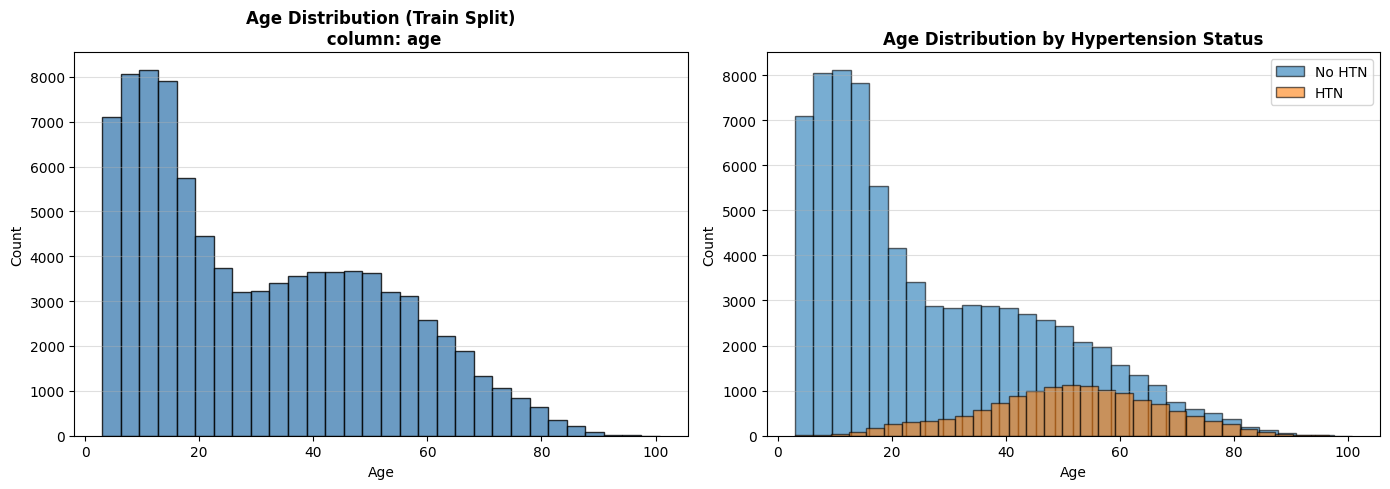

count   90713.0000
mean       30.8245
std        20.8488
min         3.0100
25%        12.5000
50%        26.0400
75%        47.2200
max       100.7100
Name: age, dtype: float64


In [85]:
age_col = next((c for c in X_e3_tr.columns if 'age' in c.lower()), None)

if age_col:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(X_e3_tr[age_col].dropna(), bins=30, edgecolor='black', color='steelblue', alpha=0.8)
    axes[0].set_title(f'Age Distribution (Train Split)\n column: {age_col}', fontweight='bold')
    axes[0].set_xlabel('Age')
    axes[0].set_ylabel('Count')
    axes[0].grid(axis='y', alpha=0.4)
    
    # By target
    for label, grp in X_e3_tr.groupby(y_e3_tr):
        axes[1].hist(grp[age_col].dropna(), bins=30, alpha=0.6,
                     label='HTN' if label == 1 else 'No HTN', edgecolor='black')
    axes[1].set_title(f'Age Distribution by Hypertension Status', fontweight='bold')
    axes[1].set_xlabel('Age')
    axes[1].set_ylabel('Count')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.4)
    
    plt.tight_layout()
    plt.show()
    
    print(X_e3_tr[age_col].describe())
else:
    print("No age column found in X_e3_tr")

In [ ]:
get age 

In [75]:
e3_feat_names

['sex',
 'age',
 'Total_Energy',
 'fg6',
 'fg7',
 'fg8',
 'fg9',
 'fg5',
 'Total_Fat',
 'Total_Iron',
 'Total_Riboflavin',
 'Total_VitaminC',
 'fg19',
 'fg11',
 'fg12',
 'fg15',
 'fg17',
 'fg18',
 'cu',
 'fg21',
 'fg23',
 'fg24',
 'fg26',
 'fg27',
 'fg3',
 'fg4',
 'mos_lactation',
 'strrec_anthro',
 'psurec_anthro',
 'provcode_anthro',
 'mos_preg',
 'ethnicity',
 'anthro_group',
 'fe_smoking_level',
 'fe_alcohol_level',
 'bmi',
 'whr']

In [ ]:
# ── 2-Stage Optimization Config ───────────────────────────────────────────────
# Reduce E3_S1_TRIALS / E3_S2_REFINE for faster runs (lower quality).
# Increase for publication-quality results.

E3_S1_TRIALS    = 15    # random param trials per (model, sampling) — Stage 1
E3_S1_EPOCHS    = 80    # tree iterations during Stage-1 CV
E3_S1_FOLDS     = 2     # CV folds in Stage 1
E3_TOP_K_S1     = 5     # top configs carried forward to Stage 2

E3_S2_REFINE    = 2     # local perturbations per top config — Stage 2
E3_S2_EPOCHS    = 200   # tree iterations during Stage-2 CV
E3_S2_FOLDS     = 3     # CV folds in Stage 2
E3_TOP_K_S2     = 2     # best Stage-2 configs used for final training

E3_FINAL_EPOCHS = 400   # tree iterations for the final (full-train) model
THRESHOLD_GRID  = np.round(np.arange(0.35, 0.70, 0.05), 2)

# ── Parameter search spaces ───────────────────────────────────────────────────
E3_MODEL_SPACES = {
    'logreg': {
        'C':       loguniform(1e-5, 1e3),
        'solver':  ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga'],
        'penalty': ['l2', 'l1', 'elasticnet'],
        'max_iter': randint(500, 5000),
    },
    'catboost': {
        'learning_rate':       loguniform(0.001, 0.5),
        'depth':               randint(4, 12),
        'l2_leaf_reg':         loguniform(1e-2, 100),
        'random_strength':     uniform(0.0, 2.5),
        'bagging_temperature': uniform(0.0, 2.0),
    },
}

_n_s2_cands = E3_TOP_K_S1 * (E3_S2_REFINE + 1)
print(f"\nStage 1 : {E3_S1_TRIALS} trials × {E3_S1_FOLDS} folds, top-{E3_TOP_K_S1} kept")
print(f"Stage 2 : ~{_n_s2_cands} candidates × {E3_S2_FOLDS} folds, top-{E3_TOP_K_S2} for final")
print(f"Final   : {E3_FINAL_EPOCHS} epochs, threshold swept on Cal set")
print(f"Total   : {len(SAMPLING_METHODS)} samplings × {len(MODEL_NAMES)} models = {len(SAMPLING_METHODS)*len(MODEL_NAMES)} combos")

# ── 2-Stage Optimization + Final Training Loop ────────────────────────────────
e3_stage1_results = {}    # (sampling, model) → DataFrame of Stage-1 trial results
e3_stage2_results = {}    # (sampling, model) → DataFrame of Stage-2 trial results
e3_best_configs   = {}    # (sampling, model) → list of best Stage-2 params dicts
e3_results        = []    # pre-calibration test metrics
e3_models         = {}    # (sampling, model) → fitted final model
e3_tr_data        = {}    # (sampling, model) → (X_tr_proc, y_tr_proc)

for sampling in SAMPLING_METHODS:
    use_cw = sampling in CW_SAMPLINGS
    print(f"\n{'═'*68}")
    print(f"Sampling: {sampling:12s}  |  class-weight active: {use_cw}")
    print(f"{'═'*68}")

    for model_name in MODEL_NAMES:
        key = (sampling, model_name)

        # ── Stage 1: broad random search ──────────────────────────────────────
        trials = list(ParameterSampler(
            E3_MODEL_SPACES[model_name], n_iter=E3_S1_TRIALS, random_state=E3_SEED))
        s1_rows = []
        for i, params in enumerate(trials, start=1):
            try:
                cv_met = e3_evaluate_params_cv(
                    model_name, params, sampling,
                    X_e3_tr_imp, y_e3_tr,
                    E3_S1_EPOCHS, E3_S1_FOLDS, seed=E3_SEED)
                s1_rows.append({'trial': i, 'params': params, **cv_met})
            except Exception as exc:
                s1_rows.append({'trial': i, 'params': params,
                                'stage_score': -999.0, 'error': str(exc)})

        df_s1 = (pd.DataFrame(s1_rows)
                   .sort_values('stage_score', ascending=False)
                   .reset_index(drop=True))
        e3_stage1_results[key] = df_s1
        top_s1_params = df_s1.head(E3_TOP_K_S1)['params'].tolist()
        s1_best_score = float(df_s1.iloc[0].get('stage_score', -999))

        # ── Stage 2: refine top-K configs ─────────────────────────────────────
        candidates = e3_refine_candidates(top_s1_params, n_refine=E3_S2_REFINE, seed=E3_SEED)
        s2_rows = []
        for i, params in enumerate(candidates, start=1):
            try:
                cv_met = e3_evaluate_params_cv(
                    model_name, params, sampling,
                    X_e3_tr_imp, y_e3_tr,
                    E3_S2_EPOCHS, E3_S2_FOLDS, seed=E3_SEED)
                s2_rows.append({'trial': i, 'params': params, **cv_met})
            except Exception as exc:
                s2_rows.append({'trial': i, 'params': params,
                                'stage_score': -999.0, 'error': str(exc)})

        df_s2 = (pd.DataFrame(s2_rows)
                   .sort_values('stage_score', ascending=False)
                   .reset_index(drop=True))
        e3_stage2_results[key] = df_s2
        best_params_list = df_s2.head(E3_TOP_K_S2)['params'].tolist()
        e3_best_configs[key]   = best_params_list
        s2_best_score = float(df_s2.iloc[0].get('stage_score', -999))

        print(f"  {model_name:14s}  S1={s1_best_score:.4f}  →  S2={s2_best_score:.4f}", end='  ')

        # ── Final training: full sampled train + threshold on Cal ──────────────
        X_tr_s, y_tr_s = e3_get_sampled_train(
            X_e3_tr_imp, y_e3_tr, sampling,
            e3_scaler, e3_ohe, e3_num_cols, e3_cat_cols)
        y_tr_s = np.asarray(y_tr_s, dtype=int)

        final_model = None
        final_score = -np.inf
        final_thr   = 0.5

        for params in best_params_list:
            mdl = e3_build_model_for_search(
                model_name, params, use_cw, y_tr_s, E3_FINAL_EPOCHS, seed=E3_SEED)
            try:
                mdl.fit(X_tr_s, y_tr_s)
            except Exception as exc:
                msg = str(exc).lower()
                if 'gpu' in msg or 'cuda' in msg or 'device' in msg:
                    try:
                        if   model_name == 'catboost': mdl.set_params(task_type='CPU')
                        elif model_name == 'xgboost':  mdl.set_params(device='cpu')
                        mdl.fit(X_tr_s, y_tr_s)
                    except Exception:
                        continue
                else:
                    continue

            p_cal_v = np.clip(mdl.predict_proba(X_e3_cal_proc)[:, 1], 1e-9, 1 - 1e-9)
            local_s, local_thr = -np.inf, 0.5
            for thr in THRESHOLD_GRID:
                yp = (p_cal_v >= thr).astype(int)
                s  = 0.60 * accuracy_score(y_e3_cal, yp) + \
                     0.40 * recall_score(y_e3_cal, yp, zero_division=0)
                if s > local_s:
                    local_s, local_thr = s, float(thr)

            if local_s > final_score:
                final_score, final_model, final_thr = local_s, mdl, local_thr

        if final_model is None:
            print("FAILED — no valid model")
            continue

        y_proba = np.clip(final_model.predict_proba(X_e3_te_proc)[:, 1], 1e-9, 1 - 1e-9)
        met = e3_metrics(y_e3_te, y_proba, final_thr)

        e3_models[key]  = final_model
        e3_tr_data[key] = (X_tr_s, y_tr_s)
        e3_results.append({
            'sampling': sampling, 'model': model_name, 'threshold': final_thr,
            **{k: round(v, 4) for k, v in met.items()},
        })
        print(f"acc={met['accuracy']:.3f}  rec={met['recall']:.3f}  auc={met['auc']:.3f}")

print(f"\n{'═'*68}")
print(f"2-Stage Optimization complete.  Models stored: {len(e3_models)}")

# ── Save stage summaries ──────────────────────────────────────────────────────
_s1_rows = [{'sampling': s, 'model': m,
              'best_stage1_score': float(df.iloc[0].get('stage_score', np.nan)),
              'best_acc_cv':       float(df.iloc[0].get('accuracy_mean', np.nan)),
              'best_rec_cv':       float(df.iloc[0].get('recall_mean', np.nan))}
            for (s, m), df in e3_stage1_results.items()]
_s2_rows = [{'sampling': s, 'model': m,
              'best_stage2_score': float(df.iloc[0].get('stage_score', np.nan)),
              'best_acc_cv':       float(df.iloc[0].get('accuracy_mean', np.nan)),
              'best_rec_cv':       float(df.iloc[0].get('recall_mean', np.nan)),
              'best_thr_cv':       float(df.iloc[0].get('threshold_mean', np.nan))}
            for (s, m), df in e3_stage2_results.items()]

pd.DataFrame(_s1_rows).to_csv(E3_DIR / 'stage1_summary.csv', index=False)
pd.DataFrame(_s2_rows).to_csv(E3_DIR / 'stage2_summary.csv', index=False)

print("\n── Stage 2 CV Summary (best score per model × sampling) ──")

display(pd.DataFrame(_s2_rows).sort_values('best_stage2_score', ascending=False).reset_index(drop=True))
display(pd.DataFrame(_s2_rows).sort_values('best_stage2_score', ascending=False).reset_index(drop=True))



Stage 1 : 15 trials × 2 folds, top-5 kept
Stage 2 : ~15 candidates × 3 folds, top-2 for final
Final   : 400 epochs, threshold swept on Cal set
Total   : 6 samplings × 2 models = 12 combos



════════════════════════════════════════════════════════════════════
Sampling: base          |  class-weight active: False
════════════════════════════════════════════════════════════════════
  logreg          S1=0.6746  →  S2=0.6750  acc=0.834  rec=0.445  auc=0.849
  catboost        S1=0.7681  →  S2=0.7574  acc=0.813  rec=0.586  auc=0.848

════════════════════════════════════════════════════════════════════
Sampling: smote         |  class-weight active: False
════════════════════════════════════════════════════════════════════
  logreg          S1=0.7653  →  S2=0.7639  acc=0.722  rec=0.867  auc=0.848
  catboost        S1=0.7686  →  S2=0.7674  acc=0.729  rec=0.832  auc=0.838

════════════════════════════════════════════════════════════════════
Sampling: smotenc       |  class-weight active: False
════════════════════════════════════════════════════════════════════
  logreg          S1=0.7653  →  S2=0.7639  acc=0.722  rec=0.867  auc=0.848
  catboost        S1=0.7686  →  S2=0.7674  acc

,sampling,model,best_stage2_score,best_acc_cv,best_rec_cv,best_thr_cv
0,cw,catboost,0.7683,0.7249,0.8652,0.5000
1,smotenc,catboost,0.7674,0.7468,0.8069,0.3500
2,smotecw,catboost,0.7674,0.7468,0.8069,0.3500
3,smote,catboost,0.7674,0.7468,0.8069,0.3500
4,smotencw,catboost,0.7674,0.7468,0.8069,0.3500
5,cw,logreg,0.7641,0.7173,0.8730,0.4500
6,smote,logreg,0.7639,0.7153,0.8765,0.4333
7,smotenc,logreg,0.7639,0.7153,0.8765,0.4333
8,smotecw,logreg,0.7639,0.7153,0.8765,0.4333
9,smotencw,logreg,0.7639,0.7153,0.8765,0.4333


,sampling,model,best_stage2_score,best_acc_cv,best_rec_cv,best_thr_cv
0,cw,catboost,0.7683,0.7249,0.8652,0.5000
1,smotenc,catboost,0.7674,0.7468,0.8069,0.3500
2,smotecw,catboost,0.7674,0.7468,0.8069,0.3500
3,smote,catboost,0.7674,0.7468,0.8069,0.3500
4,smotencw,catboost,0.7674,0.7468,0.8069,0.3500
5,cw,logreg,0.7641,0.7173,0.8730,0.4500
6,smote,logreg,0.7639,0.7153,0.8765,0.4333
7,smotenc,logreg,0.7639,0.7153,0.8765,0.4333
8,smotecw,logreg,0.7639,0.7153,0.8765,0.4333
9,smotencw,logreg,0.7639,0.7153,0.8765,0.4333


In [78]:
# ── EXP3-C · LightGBM-Only Training  (appends to e3_results / e3_models) ─────
# Run this cell standalone — it appends to the same e3_results / e3_models /
# e3_tr_data dicts so all downstream cells (pre-cal, calibration, SHAP, LIME)
# will see logreg + catboost + lightgbm together.
# Re-run pre-calibration and all cells after this one once it finishes.

import os, contextlib
from lightgbm import LGBMClassifier
from copy import deepcopy
from sklearn.model_selection import ParameterSampler, StratifiedKFold
from scipy.stats import loguniform, randint, uniform as sp_uniform
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                              f1_score, roc_auc_score, log_loss)

@contextlib.contextmanager
def _quiet_stderr():
    """Redirect file-descriptor 2 to /dev/null to suppress C-level stderr (e.g. OpenCL warnings)."""
    devnull_fd = os.open(os.devnull, os.O_WRONLY)
    saved_fd   = os.dup(2)
    os.dup2(devnull_fd, 2)
    try:
        yield
    finally:
        os.dup2(saved_fd, 2)
        os.close(saved_fd)
        os.close(devnull_fd)

_LGB_SPACES = {
    'learning_rate':     loguniform(0.005, 0.40),
    'max_depth':         randint(3, 12),
    'num_leaves':        randint(20, 200),
    'min_child_samples': randint(5, 50),
    'subsample':         sp_uniform(0.5, 0.5),
    'colsample_bytree':  sp_uniform(0.5, 0.5),
    'reg_lambda':        loguniform(1e-3, 100),
    'reg_alpha':         loguniform(1e-3, 10),
}

def _build_lgb(params, use_cw, y_sample, epoch_budget, seed=42):
    use_gpu = bool(USE_GPU_WHEN_AVAILABLE and torch_cuda_available)
    n_pos = int(np.asarray(y_sample).sum())
    n_neg = len(y_sample) - n_pos
    pos_w = float(n_neg) / max(n_pos, 1)
    p = deepcopy(params)
    md = p.get('max_depth', 6)
    return LGBMClassifier(
        n_estimators     = int(epoch_budget),
        learning_rate    = max(1e-4, float(p.get('learning_rate', 0.1))),
        max_depth        = int(md) if md != -1 else -1,
        num_leaves       = max(2, int(round(p.get('num_leaves', 31)))),
        subsample        = float(np.clip(p.get('subsample', 0.8), 0.1, 1.0)),
        colsample_bytree = float(np.clip(p.get('colsample_bytree', 0.8), 0.1, 1.0)),
        reg_lambda       = max(0.0, float(p.get('reg_lambda', 1.0))),
        reg_alpha        = max(0.0, float(p.get('reg_alpha', 0.0))),
        min_child_samples= max(1, int(round(p.get('min_child_samples', 20)))),
        scale_pos_weight = pos_w if use_cw else 1.0,
        device_type      = 'gpu' if use_gpu else 'cpu',
        random_state     = seed,
        verbose          = -1,
    )

def _lgb_fit(mdl, X, y):
    """Fit LightGBM while suppressing C-level OpenCL compiler warnings."""
    with _quiet_stderr():
        mdl.fit(X, y)

def _lgb_cv(params, sampling, X_tr_imp, y_tr, epoch_budget, n_splits, seed):
    use_cw_ = sampling in CW_SAMPLINGS
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    thr_grid = np.round(np.arange(0.35, 0.70, 0.05), 2)
    fold_rows = []
    y_arr = np.asarray(y_tr, dtype=int)
    for fold_i, (tr_idx, va_idx) in enumerate(splitter.split(X_tr_imp, y_arr), start=1):
        Xf_tr = X_tr_imp.iloc[tr_idx]; Xf_va = X_tr_imp.iloc[va_idx]
        yf_tr = y_arr[tr_idx];         yf_va = y_arr[va_idx]
        f_sc, f_ohe, _ = e3_fit_enc_scaler(Xf_tr, e3_num_cols, e3_cat_cols)
        Xf_tr_s, yf_tr_s = e3_get_sampled_train(Xf_tr, yf_tr, sampling, f_sc, f_ohe,
                                                  e3_num_cols, e3_cat_cols, seed=seed)
        yf_tr_s = np.asarray(yf_tr_s, dtype=int)
        Xf_va_p = e3_encode_scale(f_sc, f_ohe, Xf_va, e3_num_cols, e3_cat_cols)
        mdl = _build_lgb(params, use_cw_, yf_tr_s, epoch_budget, seed)
        try:
            _lgb_fit(mdl, Xf_tr_s, yf_tr_s)
        except Exception as exc:
            if 'gpu' in str(exc).lower() or 'cuda' in str(exc).lower():
                mdl.set_params(device_type='cpu')
                _lgb_fit(mdl, Xf_tr_s, yf_tr_s)
            else:
                raise
        p_val = np.clip(mdl.predict_proba(Xf_va_p)[:, 1], 1e-9, 1-1e-9)
        best_obj, best_met, best_thr = -np.inf, None, 0.5
        for thr in thr_grid:
            yp  = (p_val >= thr).astype(int)
            acc = accuracy_score(yf_va, yp)
            rec = recall_score(yf_va, yp, zero_division=0)
            obj = 0.60*acc + 0.40*rec
            if obj > best_obj:
                best_obj = obj
                best_met = dict(
                    accuracy  = acc, recall = rec,
                    precision = precision_score(yf_va, yp, zero_division=0),
                    f1        = f1_score(yf_va, yp, zero_division=0),
                    auc       = roc_auc_score(yf_va, p_val) if np.unique(yf_va).size > 1 else 0.5,
                    logloss   = log_loss(yf_va, p_val),
                )
                best_thr = float(thr)
        best_met['fold'] = fold_i; best_met['best_threshold'] = best_thr
        fold_rows.append(best_met)
    dfc = pd.DataFrame(fold_rows)
    s = {k+'_mean': float(dfc[k].mean()) for k in ['accuracy','recall','precision','f1','auc','logloss']}
    s.update({k+'_std': float(dfc[k].std(ddof=0)) for k in ['accuracy','recall','f1','logloss']})
    s['threshold_mean'] = float(dfc['best_threshold'].mean())
    s['stage_score'] = (0.60*s['accuracy_mean'] + 0.40*s['recall_mean']
        + 0.05*s['f1_mean'] - 0.08*s['logloss_mean']
        - 0.03*s['accuracy_std'] - 0.03*s['recall_std'])
    return s

_lgb_s1_results = {}
_lgb_s2_results = {}

for sampling in SAMPLING_METHODS:
    use_cw = sampling in CW_SAMPLINGS
    key    = (sampling, 'lightgbm')
    print(f"\n{'═'*68}")
    print(f"LightGBM | Sampling: {sampling:12s}  |  class-weight: {use_cw}")
    print(f"{'═'*68}")

    # ── Stage 1 ───────────────────────────────────────────────────────────
    trials  = list(ParameterSampler(_LGB_SPACES, n_iter=E3_S1_TRIALS, random_state=E3_SEED))
    s1_rows = []
    for i, params in enumerate(trials, start=1):
        try:
            cv_met = _lgb_cv(params, sampling, X_e3_tr_imp, y_e3_tr,
                             E3_S1_EPOCHS, E3_S1_FOLDS, E3_SEED)
            s1_rows.append({'trial': i, 'params': params, **cv_met})
        except Exception as exc:
            s1_rows.append({'trial': i, 'params': params, 'stage_score': -999.0, 'error': str(exc)})

    df_s1 = pd.DataFrame(s1_rows).sort_values('stage_score', ascending=False).reset_index(drop=True)
    _lgb_s1_results[key] = df_s1
    top_s1 = df_s1.head(E3_TOP_K_S1)['params'].tolist()
    s1_best = float(df_s1.iloc[0].get('stage_score', -999))

    # ── Stage 2 ───────────────────────────────────────────────────────────
    candidates = e3_refine_candidates(top_s1, n_refine=E3_S2_REFINE, seed=E3_SEED)
    s2_rows = []
    for i, params in enumerate(candidates, start=1):
        try:
            cv_met = _lgb_cv(params, sampling, X_e3_tr_imp, y_e3_tr,
                             E3_S2_EPOCHS, E3_S2_FOLDS, E3_SEED)
            s2_rows.append({'trial': i, 'params': params, **cv_met})
        except Exception as exc:
            s2_rows.append({'trial': i, 'params': params, 'stage_score': -999.0, 'error': str(exc)})

    df_s2 = pd.DataFrame(s2_rows).sort_values('stage_score', ascending=False).reset_index(drop=True)
    _lgb_s2_results[key] = df_s2
    best_params_list = df_s2.head(E3_TOP_K_S2)['params'].tolist()
    s2_best = float(df_s2.iloc[0].get('stage_score', -999))
    print(f"  S1 best={s1_best:.4f}  →  S2 best={s2_best:.4f}", end="  ")

    # ── Final training on full train split ────────────────────────────────
    X_tr_s_lgb, y_tr_s_lgb = e3_get_sampled_train(
        X_e3_tr_imp, y_e3_tr, sampling, e3_scaler, e3_ohe,
        e3_num_cols, e3_cat_cols)
    y_tr_s_lgb = np.asarray(y_tr_s_lgb, dtype=int)

    final_model, final_score, final_thr = None, -np.inf, 0.5
    for params in best_params_list:
        mdl = _build_lgb(params, use_cw, y_tr_s_lgb, E3_FINAL_EPOCHS, E3_SEED)
        try:
            _lgb_fit(mdl, X_tr_s_lgb, y_tr_s_lgb)
        except Exception as exc:
            if 'gpu' in str(exc).lower() or 'cuda' in str(exc).lower():
                try:
                    mdl.set_params(device_type='cpu')
                    _lgb_fit(mdl, X_tr_s_lgb, y_tr_s_lgb)
                except:
                    continue
            else:
                continue
        p_cal_v = np.clip(mdl.predict_proba(X_e3_cal_proc)[:, 1], 1e-9, 1-1e-9)
        for thr in THRESHOLD_GRID:
            yp  = (p_cal_v >= thr).astype(int)
            s_  = 0.60*accuracy_score(y_e3_cal, yp) + 0.40*recall_score(y_e3_cal, yp, zero_division=0)
            if s_ > final_score:
                final_score, final_model, final_thr = s_, mdl, float(thr)

    if final_model is None:
        print("FAILED — no valid model"); continue

    y_proba_lgb = np.clip(final_model.predict_proba(X_e3_te_proc)[:, 1], 1e-9, 1-1e-9)
    met = e3_metrics(y_e3_te, y_proba_lgb, final_thr)

    e3_models[key]  = final_model
    e3_tr_data[key] = (X_tr_s_lgb, y_tr_s_lgb)
    e3_results.append({
        'sampling': sampling, 'model': 'lightgbm', 'threshold': final_thr,
        **{k: round(v, 4) for k, v in met.items()},
    })
    print(f"acc={met['accuracy']:.3f}  rec={met['recall']:.3f}  auc={met['auc']:.3f}")

print(f"\n{'═'*68}")
print(f"LightGBM training complete.  Total entries in e3_models: {len(e3_models)}")
print("Now re-run cells 13 onwards (pre-calibration → calibration → post-cal → SHAP → LIME)")

# Save stage summaries
_l1 = [{'sampling': s, 'model': 'lightgbm',
         'best_stage1_score': float(df.iloc[0].get('stage_score', float('nan'))),
         'best_acc_cv':       float(df.iloc[0].get('accuracy_mean', float('nan'))),
         'best_rec_cv':       float(df.iloc[0].get('recall_mean', float('nan')))}
        for (s, _), df in _lgb_s1_results.items()]
_l2 = [{'sampling': s, 'model': 'lightgbm',
         'best_stage2_score': float(df.iloc[0].get('stage_score', float('nan'))),
         'best_acc_cv':       float(df.iloc[0].get('accuracy_mean', float('nan'))),
         'best_rec_cv':       float(df.iloc[0].get('recall_mean', float('nan'))),
         'best_thr_cv':       float(df.iloc[0].get('threshold_mean', float('nan')))}
        for (s, _), df in _lgb_s2_results.items()]
pd.DataFrame(_l1).to_csv(E3_DIR / 'lgb_stage1_summary.csv', index=False)
pd.DataFrame(_l2).to_csv(E3_DIR / 'lgb_stage2_summary.csv', index=False)
print("Stage summaries saved →", E3_DIR)



════════════════════════════════════════════════════════════════════
LightGBM | Sampling: base          |  class-weight: False
════════════════════════════════════════════════════════════════════
  S1 best=0.6921  →  S2 best=0.6980  acc=0.828  rec=0.513  auc=0.852

════════════════════════════════════════════════════════════════════
LightGBM | Sampling: smote         |  class-weight: False
════════════════════════════════════════════════════════════════════
  S1 best=0.7609  →  S2 best=0.7661  acc=0.730  rec=0.838  auc=0.838

════════════════════════════════════════════════════════════════════
LightGBM | Sampling: smotenc       |  class-weight: False
════════════════════════════════════════════════════════════════════
  S1 best=0.7609  →  S2 best=0.7661  acc=0.730  rec=0.838  auc=0.838

════════════════════════════════════════════════════════════════════
LightGBM | Sampling: cw            |  class-weight: True
════════════════════════════════════════════════════════════════════
  S1 b

PRE-CALIBRATION TEST-SET METRICS  (sorted by 0.5·acc + 0.5·recall)


,sampling,model,accuracy,recall,precision,f1,auc,logloss,ece,combined
1,cw,logreg,0.7177,0.8749,0.3357,0.4852,0.8484,0.4950,0.2134,0.7963
2,smote,logreg,0.7218,0.8669,0.3381,0.4865,0.8483,0.4930,0.2078,0.7944
3,smotenc,logreg,0.7218,0.8669,0.3381,0.4865,0.8483,0.4930,0.2078,0.7944
4,smotecw,logreg,0.7218,0.8669,0.3381,0.4865,0.8483,0.4930,0.2078,0.7944
5,smotencw,logreg,0.7218,0.8669,0.3381,0.4865,0.8483,0.4930,0.2078,0.7944
6,cw,lightgbm,0.7428,0.8351,0.3536,0.4968,0.8522,0.4691,0.1999,0.7890
7,cw,catboost,0.7300,0.8479,0.3431,0.4885,0.8486,0.4560,0.1877,0.7890
8,smote,lightgbm,0.7295,0.8375,0.3413,0.4849,0.8378,0.3705,0.1111,0.7835
9,smotenc,lightgbm,0.7295,0.8375,0.3413,0.4849,0.8378,0.3705,0.1111,0.7835
10,smotecw,lightgbm,0.7295,0.8375,0.3413,0.4849,0.8378,0.3705,0.1111,0.7835



Saved: /workspace/Thesis-part-2/exp3_logreg_cat/pre_calibration_results.csv


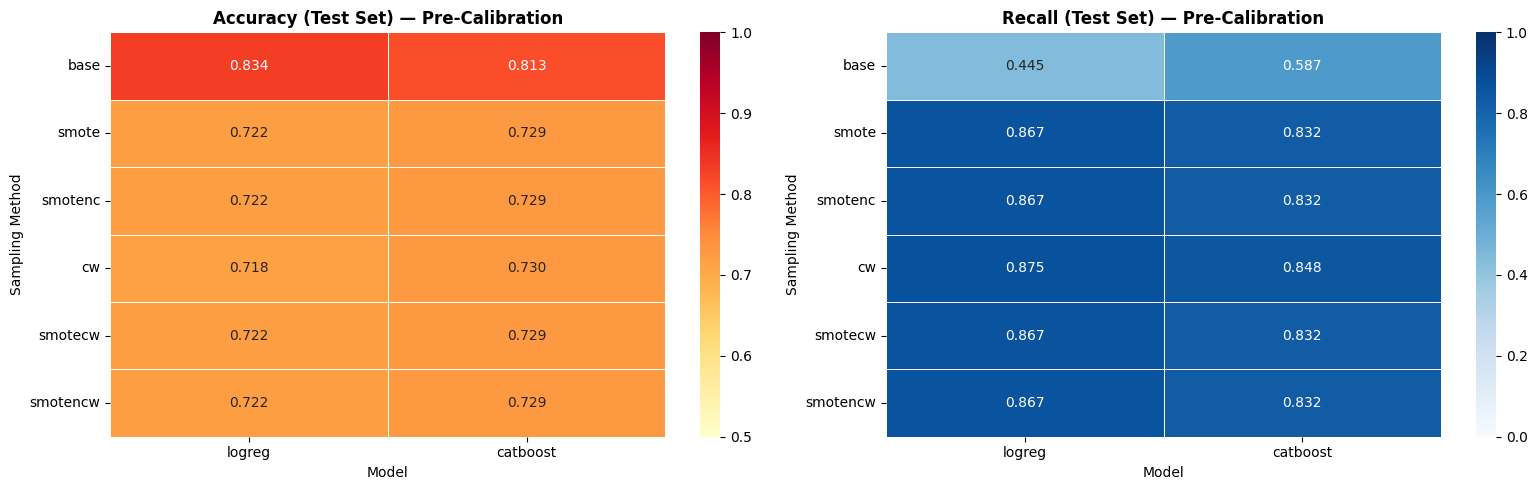

Saved: /workspace/Thesis-part-2/exp3_logreg_cat/plots/pre_cal_heatmaps.png


In [79]:
# ── EXP3 · Pre-Calibration Test-Set Metrics (all 36 models) ─────────────────

e3_pre_df = pd.DataFrame([r for r in e3_results if 'error' not in r])
e3_pre_df['combined'] = (e3_pre_df['accuracy'] + e3_pre_df['recall']) / 2.0
e3_pre_df = e3_pre_df.sort_values(['combined', 'auc'], ascending=False).reset_index(drop=True)
e3_pre_df.index += 1

print("=" * 80)
print("PRE-CALIBRATION TEST-SET METRICS  (sorted by 0.5·acc + 0.5·recall)")
print("=" * 80)
display(e3_pre_df[[
    'sampling', 'model', 'accuracy', 'recall', 'precision', 'f1', 'auc', 'logloss', 'ece', 'combined'
]])

# Save
_pre_path = E3_DIR / 'pre_calibration_results.csv'
e3_pre_df.to_csv(_pre_path, index=True, index_label='rank')
print(f"\nSaved: {_pre_path}")

# ── Heatmap: accuracy by sampling × model ────────────────────────────────────
pivot_acc = e3_pre_df.pivot_table(
    values='accuracy', index='sampling', columns='model', aggfunc='first')
pivot_acc = pivot_acc.reindex(index=SAMPLING_METHODS, columns=MODEL_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(pivot_acc, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], vmin=0.5, vmax=1.0)
axes[0].set_title('Accuracy (Test Set) — Pre-Calibration', fontweight='bold')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Sampling Method')

pivot_rec = e3_pre_df.pivot_table(
    values='recall', index='sampling', columns='model', aggfunc='first')
pivot_rec = pivot_rec.reindex(index=SAMPLING_METHODS, columns=MODEL_NAMES)
sns.heatmap(pivot_rec, annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.5, ax=axes[1], vmin=0.0, vmax=1.0)
axes[1].set_title('Recall (Test Set) — Pre-Calibration', fontweight='bold')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Sampling Method')

plt.tight_layout()
_hm_path = E3_DIR / 'plots' / 'pre_cal_heatmaps.png'
plt.savefig(_hm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {_hm_path}")


In [80]:
# ── EXP3 · Calibration: Base · Platt · Isotonic · Venn-Abers ────────────────
# Each of the 36 trained models is calibrated with all 4 methods (144 total).
# Calibrators are fit on the CAL split; metrics reported on the TEST split.

e3_cal_results = []        # post-calibration metrics
e3_cal_probs   = {}        # (sampling, model, cal_method) → y_te_proba

for (sampling, model_name), fitted_model in e3_models.items():
    p_cal   = fitted_model.predict_proba(X_e3_cal_proc)[:, 1]
    p_te    = fitted_model.predict_proba(X_e3_te_proc)[:, 1]

    for cal_method in CAL_METHODS:
        try:
            calibrator = e3_fit_calibrator(cal_method, p_cal, y_e3_cal)
            p_te_cal   = e3_apply_calibrator(cal_method, calibrator, p_te)

            m = e3_metrics(y_e3_te, p_te_cal)
            e3_cal_probs[(sampling, model_name, cal_method)] = p_te_cal

            e3_cal_results.append({
                'sampling':    sampling,
                'model':       model_name,
                'calibration': cal_method,
                **{k: round(v, 4) for k, v in m.items()},
            })
        except Exception as exc:
            e3_cal_results.append({
                'sampling':    sampling,
                'model':       model_name,
                'calibration': cal_method,
                'error':       str(exc),
            })

print(f"Calibration complete — {len(e3_cal_results)} entries (expected 144).")


Calibration complete — 72 entries (expected 144).


POST-CALIBRATION TEST-SET METRICS  (sorted by 0.25·acc + 0.25·recall + 0.25·(1-ece) + 0.25·(1-logloss))
Calibration metrics highlighted: ECE (lower=better)  |  LogLoss (lower=better)


,sampling,model,calibration,accuracy,recall,precision,f1,auc,logloss,ece,combined
1,smote,catboost,base,0.7521,0.7822,0.3564,0.4897,0.8375,0.4139,0.1577,0.7407
2,smotenc,catboost,base,0.7521,0.7822,0.3564,0.4897,0.8375,0.4139,0.1577,0.7407
3,smotecw,catboost,base,0.7521,0.7822,0.3564,0.4897,0.8375,0.4139,0.1577,0.7407
4,smotencw,catboost,base,0.7521,0.7822,0.3564,0.4897,0.8375,0.4139,0.1577,0.7407
5,smote,lightgbm,base,0.7905,0.6382,0.3858,0.4809,0.8378,0.3705,0.1111,0.7368
...,...,...,...,...,...,...,...,...,...,...,...
68,smote,catboost,venn_abers,0.8480,0.0479,0.5011,0.0874,0.8373,0.3190,0.0065,0.6426
69,smotenc,catboost,venn_abers,0.8480,0.0479,0.5011,0.0874,0.8373,0.3190,0.0065,0.6426
70,smotecw,catboost,venn_abers,0.8480,0.0479,0.5011,0.0874,0.8373,0.3190,0.0065,0.6426
71,smotencw,catboost,venn_abers,0.8480,0.0479,0.5011,0.0874,0.8373,0.3190,0.0065,0.6426



Saved: /workspace/Thesis-part-2/exp3_logreg_cat/post_calibration_results.csv


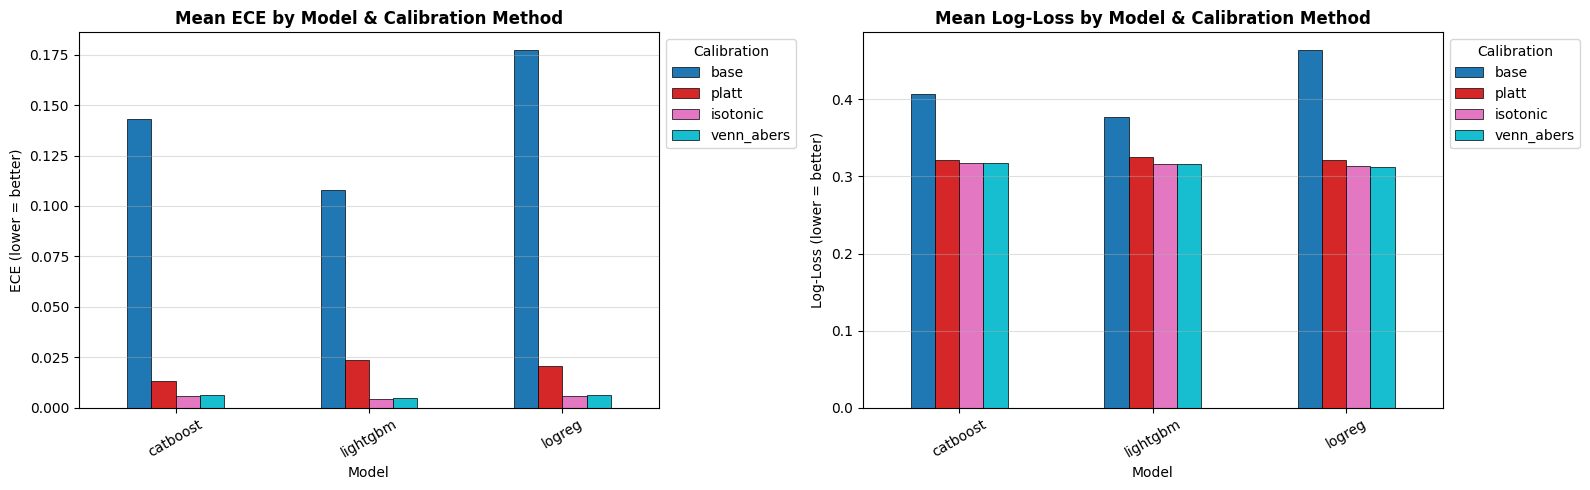

Saved: /workspace/Thesis-part-2/exp3_logreg_cat/plots/post_cal_ece_logloss.png

Best model: catboost  |  sampling: smote  |  calibration: base
  acc=0.7521  rec=0.7822  auc=0.8375  ece=0.1577  logloss=0.4139


In [97]:
# ── EXP3 · Post-Calibration Test-Set Metrics + ECE / Log-Loss ───────────────

e3_cal_df = pd.DataFrame([r for r in e3_cal_results if 'error' not in r])
e3_cal_df['combined'] = (e3_cal_df['accuracy'] + e3_cal_df['recall'] + (1 - e3_cal_df['ece']) + (1 - e3_cal_df['logloss'])) / 4.0
e3_cal_df = e3_cal_df.sort_values(['combined', 'auc'], ascending=False).reset_index(drop=True)
e3_cal_df.index += 1

print("=" * 90)
print("POST-CALIBRATION TEST-SET METRICS  (sorted by 0.25·acc + 0.25·recall + 0.25·(1-ece) + 0.25·(1-logloss))")
print("Calibration metrics highlighted: ECE (lower=better)  |  LogLoss (lower=better)")
print("=" * 90)
display(e3_cal_df[[
    'sampling', 'model', 'calibration',
    'accuracy', 'recall', 'precision', 'f1', 'auc',
    'logloss', 'ece', 'combined'
]])

# Save
_cal_path = E3_DIR / 'post_calibration_results.csv'
e3_cal_df.to_csv(_cal_path, index=True, index_label='rank')
print(f"\nSaved: {_cal_path}")

# ── ECE comparison bar chart ──────────────────────────────────────────────────
ece_pivot = e3_cal_df.pivot_table(
    values='ece', index='model', columns='calibration', aggfunc='mean')
ece_pivot = ece_pivot.reindex(columns=CAL_METHODS)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ece_pivot.plot(kind='bar', ax=axes[0], colormap='tab10', edgecolor='black', linewidth=0.5)
axes[0].set_title('Mean ECE by Model & Calibration Method', fontweight='bold')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('ECE (lower = better)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Calibration', bbox_to_anchor=(1, 1))
axes[0].grid(axis='y', alpha=0.4)

ll_pivot = e3_cal_df.pivot_table(
    values='logloss', index='model', columns='calibration', aggfunc='mean')
ll_pivot = ll_pivot.reindex(columns=CAL_METHODS)
ll_pivot.plot(kind='bar', ax=axes[1], colormap='tab10', edgecolor='black', linewidth=0.5)
axes[1].set_title('Mean Log-Loss by Model & Calibration Method', fontweight='bold')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Log-Loss (lower = better)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Calibration', bbox_to_anchor=(1, 1))
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
_ece_path = E3_DIR / 'plots' / 'post_cal_ece_logloss.png'
plt.savefig(_ece_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {_ece_path}")

# ── Identify best overall calibrated model ───────────────────────────────────
best_cal_row = e3_cal_df.iloc[0]
e3_best_key  = (best_cal_row['sampling'], best_cal_row['model'])
e3_best_model  = e3_models[e3_best_key]
e3_best_cal_m  = best_cal_row['calibration']
e3_best_sample = best_cal_row['sampling']
e3_best_mname  = best_cal_row['model']

print(f"\nBest model: {e3_best_mname}  |  sampling: {e3_best_sample}"
      f"  |  calibration: {e3_best_cal_m}")
print(f"  acc={best_cal_row['accuracy']:.4f}  rec={best_cal_row['recall']:.4f}"
      f"  auc={best_cal_row['auc']:.4f}  ece={best_cal_row['ece']:.4f}"
      f"  logloss={best_cal_row['logloss']:.4f}")


In [82]:
# ── EXP3-C · Save Best Model Bundle for Streamlit Webapp ────────────────────
# Run this cell after post-calibration to persist the winning model + full
# preprocessing pipeline as a single joblib bundle that the webapp can load.

import joblib

# Full numeric columns the KNN imputer was fit on (before collinearity filter).
# KNNImputer stores feature_names_in_ in sklearn >= 1.0.
_num_cols_full = (
    [str(c) for c in e3_knn_imp.feature_names_in_]
    if hasattr(e3_knn_imp, 'feature_names_in_')
    else list(e3_num_cols)   # fallback: already-reduced list
)

# Best threshold from the pre-calibration sweep on the cal set.
_pre_cal_entry = next(
    (r for r in e3_results
     if r.get('sampling') == e3_best_sample and r.get('model') == e3_best_mname),
    None
)
_best_threshold = float(_pre_cal_entry['threshold']) if _pre_cal_entry else 0.45

# Raw input columns as seen by the webapp form (X after FE + drops, before imputation).
_input_feature_names = list(X.columns)

_bundle = {
    # ── Core model ───────────────────────────────────────────────────────────
    'model':               e3_best_model,
    # ── Preprocessing chain ──────────────────────────────────────────────────
    'knn_imputer':         e3_knn_imp,       # fit on num_cols_full
    'cat_imputer':         e3_cat_imp,       # fit on cat_cols (may be None)
    'scaler':              e3_scaler,        # fit on num_cols_reduced (post-filter)
    'ohe':                 e3_ohe,           # fit on cat_cols (may be None)
    # ── Column metadata ──────────────────────────────────────────────────────
    'num_cols_full':       _num_cols_full,   # full numeric cols for imputer
    'num_cols_reduced':    list(e3_num_cols),# surviving numeric cols after collinearity filter
    'cat_cols':            list(e3_cat_cols),
    'feat_names':          list(e3_feat_names),   # post-transform names fed to model
    'input_feature_names': _input_feature_names,  # raw X cols shown in webapp form
    # ── Best combo metadata ──────────────────────────────────────────────────
    'threshold':           _best_threshold,
    'sampling':            e3_best_sample,
    'model_name':          e3_best_mname,
    'calibration':         e3_best_cal_m,
    'metrics': {
        'accuracy':  float(best_cal_row['accuracy']),
        'recall':    float(best_cal_row['recall']),
        'precision': float(best_cal_row['precision']),
        'f1':        float(best_cal_row['f1']),
        'auc':       float(best_cal_row['auc']),
        'logloss':   float(best_cal_row['logloss']),
        'ece':       float(best_cal_row['ece']),
    },
}

_save_path = E3_DIR / 'models' / 'best_model_bundle.joblib'
_save_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(_bundle, _save_path, compress=3)

print(f"Bundle saved → {_save_path}")
print(f"  Model      : {e3_best_mname}  |  sampling={e3_best_sample}  |  calibration={e3_best_cal_m}")
print(f"  Threshold  : {_best_threshold:.2f}")
print(f"  Input cols : {len(_input_feature_names)}")
print(f"  Model feats: {len(e3_feat_names)}")
print(f"  Metrics    : acc={_bundle['metrics']['accuracy']:.4f}  "
      f"rec={_bundle['metrics']['recall']:.4f}  "
      f"auc={_bundle['metrics']['auc']:.4f}")
print()
print("Webapp artifact path (backend.py EXP3_BUNDLE_PATH):")
print(f"  {_save_path}")


Bundle saved → /workspace/Thesis-part-2/exp3_logreg_cat/models/best_model_bundle.joblib
  Model      : lightgbm  |  sampling=cw  |  calibration=base
  Threshold  : 0.55
  Input cols : 54
  Model feats: 30
  Metrics    : acc=0.7221  rec=0.8686  auc=0.8522

Webapp artifact path (backend.py EXP3_BUNDLE_PATH):
  /workspace/Thesis-part-2/exp3_logreg_cat/models/best_model_bundle.joblib


Building SHAP explainer for: lightgbm  (sampling=cw)


100%|██████████| 300/300 [07:06<00:00,  1.42s/it]


SHAP values shape: (300, 30)


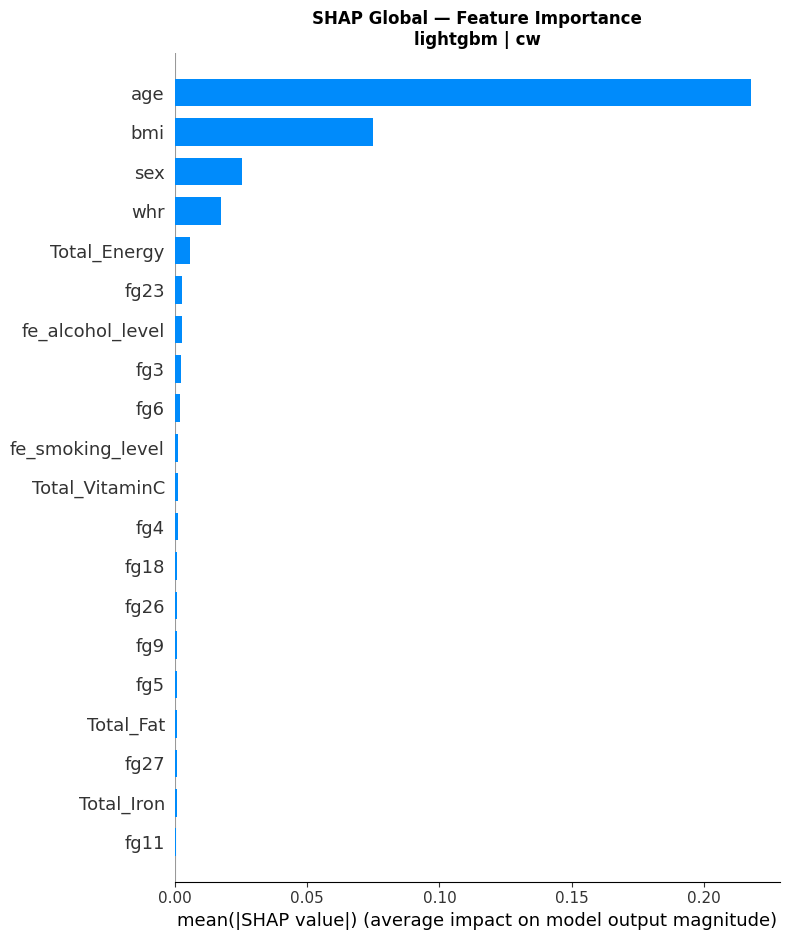

Saved: /workspace/Thesis-part-2/exp3_logreg_cat/plots/shap_global_bar.png


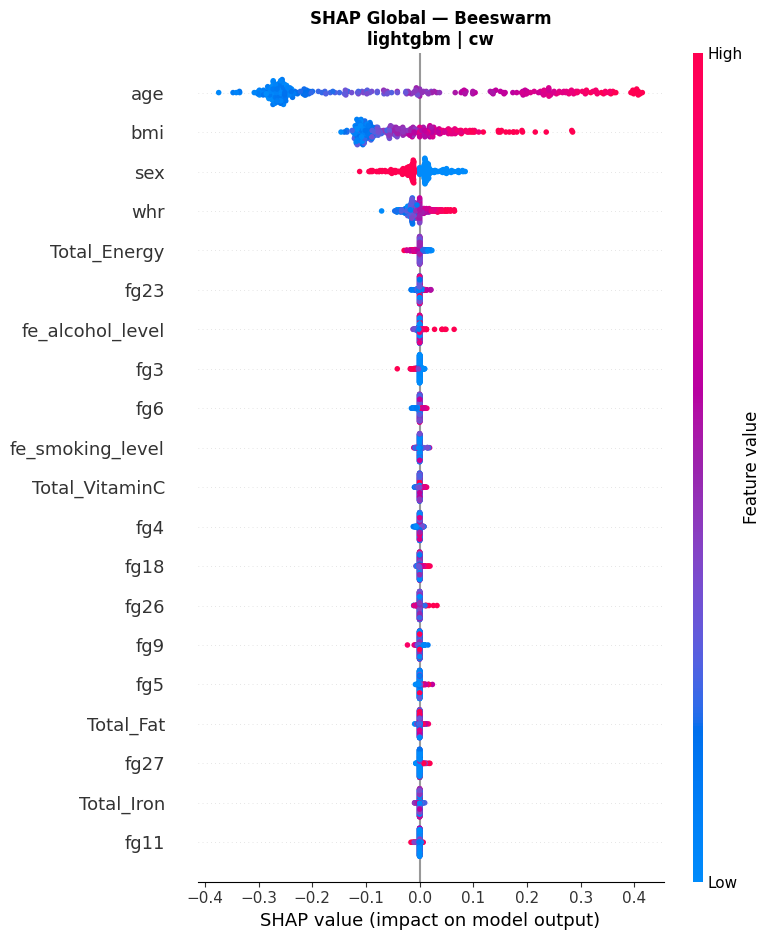

Saved: /workspace/Thesis-part-2/exp3_logreg_cat/plots/shap_global_beeswarm.png


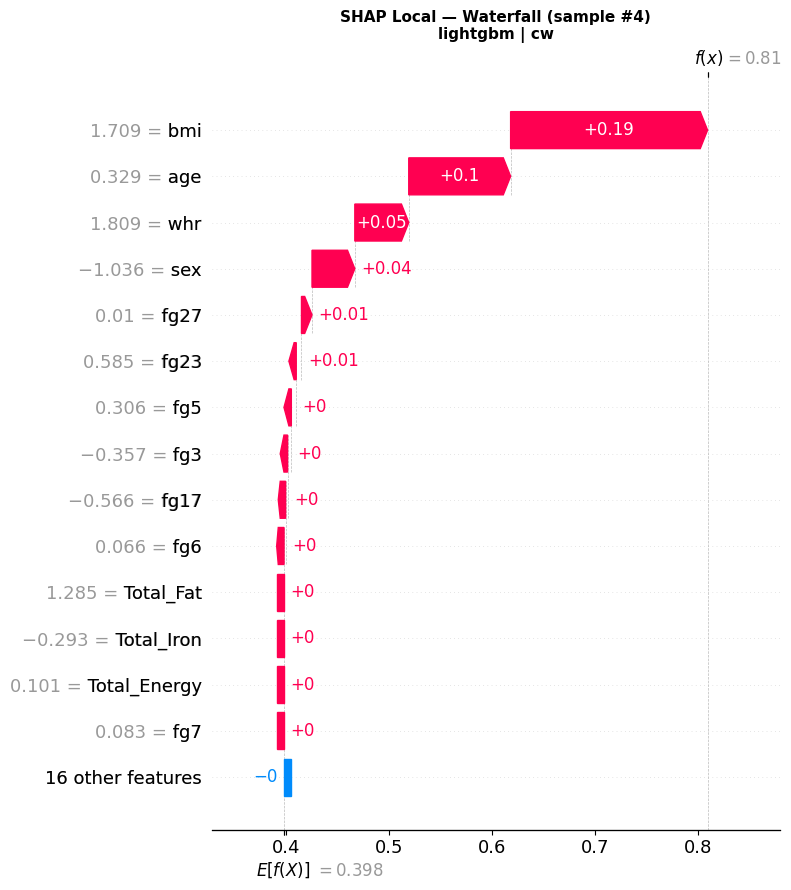

Saved: /workspace/Thesis-part-2/exp3_logreg_cat/plots/shap_local_waterfall.png


In [83]:
# ── EXP3 · SHAP Global + Local Explanation ──────────────────────────────────
# Best model identified in the previous cell (e3_best_model / e3_best_mname)

_SHAP_TEST_N   = 300   # number of test samples for global SHAP
_SHAP_BG_N     = 100   # background samples for non-tree explainers

X_e3_te_shap = X_e3_te_proc[:_SHAP_TEST_N]
feat_arr_e3  = np.array(e3_feat_names)

# ── Build SHAP explainer (auto-select by model type) ─────────────────────────
X_bg = e3_tr_data[e3_best_key][0][:_SHAP_BG_N]   # processed train background

print(f"Building SHAP explainer for: {e3_best_mname}  (sampling={e3_best_sample})")

_tree_types = ('catboost', 'xgboost', 'randomforest', 'adaboost')

try:
    if e3_best_mname in _tree_types:
        _explainer = shap.TreeExplainer(e3_best_model)
    elif e3_best_mname == 'logreg':
        _explainer = shap.LinearExplainer(e3_best_model, X_bg)
    else:
        _explainer = shap.KernelExplainer(
            lambda x: e3_best_model.predict_proba(x)[:, 1], X_bg)

    _shap_raw = _explainer.shap_values(X_e3_te_shap)

    # Normalise to class-1 array (RF returns a list)
    if isinstance(_shap_raw, list):
        _sv   = np.array(_shap_raw[1])
        _ev   = (_explainer.expected_value[1]
                 if hasattr(_explainer.expected_value, '__len__')
                 else float(_explainer.expected_value))
    else:
        _sv = np.array(_shap_raw)
        _ev = (float(_explainer.expected_value[0])
               if hasattr(_explainer.expected_value, '__len__')
               else float(_explainer.expected_value))

    print(f"SHAP values shape: {_sv.shape}")

    # ── GLOBAL — Bar chart (mean |SHAP|) ─────────────────────────────────────
    plt.figure(figsize=(10, 7))
    shap.summary_plot(_sv, X_e3_te_shap, feature_names=feat_arr_e3,
                      plot_type='bar', show=False, max_display=20)
    plt.title(f"SHAP Global — Feature Importance\n"
              f"{e3_best_mname} | {e3_best_sample}", fontweight='bold', fontsize=12)
    plt.tight_layout()
    _bar_path = E3_DIR / 'plots' / 'shap_global_bar.png'
    plt.savefig(_bar_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {_bar_path}")

    # ── GLOBAL — Beeswarm ────────────────────────────────────────────────────
    plt.figure(figsize=(10, 7))
    shap.summary_plot(_sv, X_e3_te_shap, feature_names=feat_arr_e3,
                      show=False, max_display=20)
    plt.title(f"SHAP Global — Beeswarm\n"
              f"{e3_best_mname} | {e3_best_sample}", fontweight='bold', fontsize=12)
    plt.tight_layout()
    _bees_path = E3_DIR / 'plots' / 'shap_global_beeswarm.png'
    plt.savefig(_bees_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {_bees_path}")

    # ── LOCAL — Waterfall for one HTN-positive test sample ───────────────────
    _pos_indices = np.where(y_e3_te[:_SHAP_TEST_N] == 1)[0]
    _local_idx   = int(_pos_indices[0]) if len(_pos_indices) else 0

    _exp_local = shap.Explanation(
        values       = _sv[_local_idx],
        base_values  = _ev,
        data         = X_e3_te_shap[_local_idx],
        feature_names= feat_arr_e3.tolist(),
    )
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(_exp_local, show=False, max_display=15)
    plt.title(f"SHAP Local — Waterfall (sample #{_local_idx})\n"
              f"{e3_best_mname} | {e3_best_sample}", fontweight='bold', fontsize=11)
    plt.tight_layout()
    _wf_path = E3_DIR / 'plots' / 'shap_local_waterfall.png'
    plt.savefig(_wf_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {_wf_path}")

    # ── LOCAL — Force plot (inline HTML) ─────────────────────────────────────
    shap.initjs()
    _force = shap.force_plot(
        _ev,
        _sv[_local_idx],
        X_e3_te_shap[_local_idx],
        feature_names=feat_arr_e3.tolist(),
    )
    display(_force)

except Exception as _shap_exc:
    print(f"SHAP failed: {_shap_exc}")
    print("Tip: try re-running after restarting the kernel if OOM or import issues occur.")


LIME explanation for test sample #4
True label : HTN
Predicted probability (HTN): 0.8096



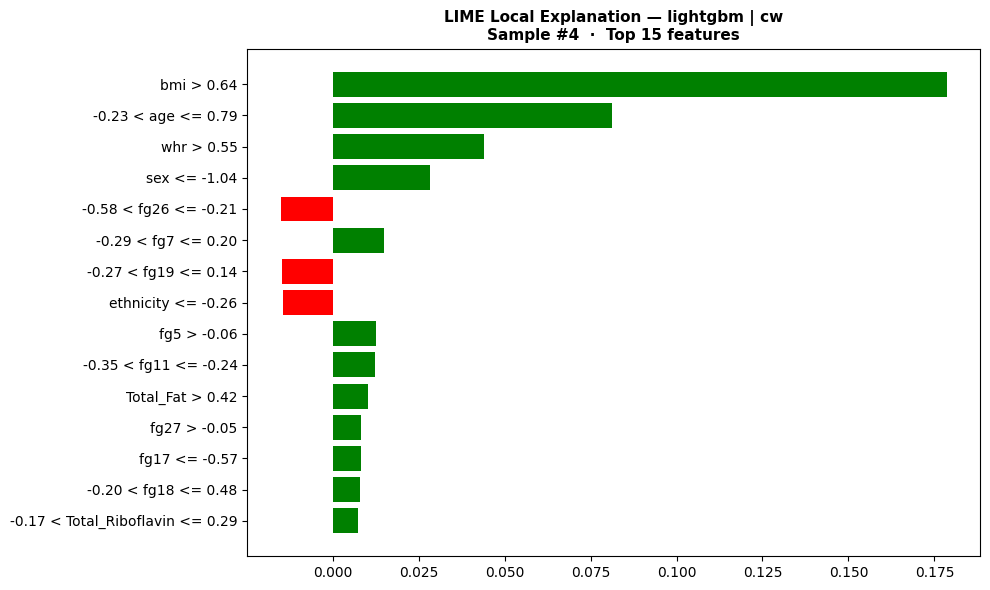

Saved: /workspace/Thesis-part-2/exp3_logreg_cat/plots/lime_local.png


,Feature Condition,LIME Weight,|Weight|
1,bmi > 0.64,0.1786,0.1786
2,-0.23 < age <= 0.79,0.0811,0.0811
3,whr > 0.55,0.0440,0.0440
4,sex <= -1.04,0.0284,0.0284
5,-0.58 < fg26 <= -0.21,-0.0151,0.0151
6,-0.29 < fg7 <= 0.20,0.0150,0.0150
7,-0.27 < fg19 <= 0.14,-0.0147,0.0147
8,ethnicity <= -0.26,-0.0145,0.0145
9,fg5 > -0.06,0.0125,0.0125
10,-0.35 < fg11 <= -0.24,0.0124,0.0124



EXP3 complete.
All plots saved to: /workspace/Thesis-part-2/exp3_logreg_cat/plots
Results CSVs  saved to: /workspace/Thesis-part-2/exp3_logreg_cat


In [84]:
# ── EXP3 · LIME Local Explanation ───────────────────────────────────────────
# Explains the same sample used in the SHAP local plot above.

_LIME_FEATURES = 15   # top features to display

_X_train_bg = e3_tr_data[e3_best_key][0]   # processed training data (numpy)

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = _X_train_bg,
    feature_names  = e3_feat_names,
    class_names    = ['No HTN', 'HTN'],
    mode           = 'classification',
    random_state   = E3_SEED,
    discretize_continuous = True,
)

def _pred_fn(X):
    return e3_best_model.predict_proba(X)

# Explain the same positive instance used for SHAP local
_lime_idx = _local_idx if '_local_idx' in dir() else 0

lime_exp = lime_explainer.explain_instance(
    data_row    = X_e3_te_proc[_lime_idx],
    predict_fn  = _pred_fn,
    num_features= _LIME_FEATURES,
    labels      = (1,),
)

# ── Inline display ────────────────────────────────────────────────────────────
print(f"LIME explanation for test sample #{_lime_idx}")
print(f"True label : {'HTN' if y_e3_te[_lime_idx] == 1 else 'No HTN'}")
print(f"Predicted probability (HTN): "
      f"{e3_best_model.predict_proba(X_e3_te_proc[[_lime_idx]])[0, 1]:.4f}")
print()

fig = lime_exp.as_pyplot_figure(label=1)
fig.set_size_inches(10, 6)
plt.title(
    f"LIME Local Explanation — {e3_best_mname} | {e3_best_sample}\n"
    f"Sample #{_lime_idx}  ·  Top {_LIME_FEATURES} features",
    fontweight='bold', fontsize=11)
plt.tight_layout()
_lime_path = E3_DIR / 'plots' / 'lime_local.png'
plt.savefig(_lime_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {_lime_path}")

# ── Text table ────────────────────────────────────────────────────────────────
lime_pairs = lime_exp.as_list(label=1)
lime_table = pd.DataFrame(lime_pairs, columns=['Feature Condition', 'LIME Weight'])
lime_table['|Weight|'] = lime_table['LIME Weight'].abs()
lime_table = lime_table.sort_values('|Weight|', ascending=False).reset_index(drop=True)
lime_table.index += 1
display(lime_table)

# ── Notebook-rendered HTML version ───────────────────────────────────────────
try:
    lime_exp.show_in_notebook(show_table=True, show_all=False)
except Exception:
    pass

print("\nEXP3 complete.")
print(f"All plots saved to: {E3_DIR / 'plots'}")
print(f"Results CSVs  saved to: {E3_DIR}")


In [95]:
# ══════════════════════════════════════════════════════════════════════════════
# EXP3_RIGOROUS_V2
# Completely separate from existing results
# Goal: accuracy > 0.75, recall > 0.85
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import StratifiedKFold, ParameterSampler
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from scipy.stats import uniform, randint

import warnings
warnings.filterwarnings("ignore")

# ══════════════════════════════════════════════════════════════════════════════
# PROCESS DATA USING EXISTING PIPELINE
# ══════════════════════════════════════════════════════════════════════════════

X_rig_tr = e3_encode_scale(
    e3_scaler,
    e3_ohe,
    X_e3_tr_imp,
    e3_num_cols,
    e3_cat_cols
)

X_rig_cal = e3_encode_scale(
    e3_scaler,
    e3_ohe,
    X_e3_cal_imp,
    e3_num_cols,
    e3_cat_cols
)

X_rig_te = e3_encode_scale(
    e3_scaler,
    e3_ohe,
    X_e3_te_imp,
    e3_num_cols,
    e3_cat_cols
)

print("Train:", X_rig_tr.shape)
print("Cal  :", X_rig_cal.shape)
print("Test :", X_rig_te.shape)

# ══════════════════════════════════════════════════════════════════════════════
# NEW STORAGE
# ══════════════════════════════════════════════════════════════════════════════

rig_models      = {}
rig_results     = []
rig_thresholds  = {}
rig_best_params = {}

# ══════════════════════════════════════════════════════════════════════════════
# SETTINGS
# ══════════════════════════════════════════════════════════════════════════════

RANDOM_STATE = 42
N_TRIALS     = 30

# Hard targets
ACC_TARGET = 0.75
REC_TARGET = 0.85

def objective(acc, rec):
    """
    Constrained objective targeting acc > 0.75 AND recall > 0.85.
    Hard-penalise when either metric is far below its floor so the
    search steers away from degenerate (all-positive / all-negative) configs.
    Once both soft floors are met, reward recall slightly more than accuracy
    because recall is harder to achieve without sacrificing accuracy.
    """
    if rec < REC_TARGET - 0.10:     # recall far below target → heavy penalty
        return rec * 0.4
    if acc < ACC_TARGET - 0.10:     # accuracy far below target → heavy penalty
        return acc * 0.4
    return 0.35 * acc + 0.65 * rec

# ══════════════════════════════════════════════════════════════════════════════
# PARAMETER SPACES
# ══════════════════════════════════════════════════════════════════════════════

spaces = {

    "logreg": {
        "C": uniform(0.01, 15),
        "solver": ["liblinear", "saga"],
        "penalty": ["l1", "l2"],
        "class_weight": ["balanced"],           # balanced forces recall-friendly fit
        "max_iter": [5000]
    },

    "lightgbm": {
        "n_estimators": randint(300, 1200),
        "learning_rate": uniform(0.005, 0.06),
        "num_leaves": randint(20, 150),
        "max_depth": randint(3, 12),
        "min_child_samples": randint(5, 50),
        "subsample": uniform(0.6, 0.4),
        "colsample_bytree": uniform(0.6, 0.4),
        "reg_alpha": uniform(0, 3),
        "reg_lambda": uniform(0, 3),
        "scale_pos_weight": uniform(1.0, 5.0),  # upweight positive class
        "class_weight": [None, "balanced"]
    },

    "catboost": {
        "iterations": randint(400, 1400),
        "learning_rate": uniform(0.005, 0.06),
        "depth": randint(4, 10),
        "l2_leaf_reg": uniform(1, 8),
        "bagging_temperature": uniform(0, 3),
        "random_strength": uniform(0, 3),
        "scale_pos_weight": uniform(1.5, 6.0)   # ensure positive-class bias
    }
}

# ══════════════════════════════════════════════════════════════════════════════
# MODEL FACTORY
# ══════════════════════════════════════════════════════════════════════════════

def build_model(name, params):

    if name == "logreg":
        return LogisticRegression(
            **params,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    elif name == "lightgbm":
        return LGBMClassifier(
            **params,
            objective="binary",
            random_state=RANDOM_STATE,
            verbosity=-1
        )

    elif name == "catboost":
        return CatBoostClassifier(
            **params,
            loss_function="Logloss",
            eval_metric="Recall",
            verbose=False,
            random_seed=RANDOM_STATE
        )

# ══════════════════════════════════════════════════════════════════════════════
# CROSS VALIDATION
# ══════════════════════════════════════════════════════════════════════════════

def evaluate_cv(model_name, params):

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    scores = []

    for tr_idx, val_idx in skf.split(X_rig_tr, y_e3_tr):

        Xtr  = X_rig_tr[tr_idx]
        Xval = X_rig_tr[val_idx]
        ytr  = y_e3_tr[tr_idx]
        yval = y_e3_tr[val_idx]

        model = build_model(model_name, params)
        model.fit(Xtr, ytr)
        probs = model.predict_proba(Xval)[:, 1]

        best_fold_score = -999

        for thr in np.arange(0.20, 0.81, 0.02):
            preds = (probs >= thr).astype(int)
            acc   = accuracy_score(yval, preds)
            rec   = recall_score(yval, preds, zero_division=0)
            score = objective(acc, rec)          # fixed: only acc & rec
            if score > best_fold_score:
                best_fold_score = score

        scores.append(best_fold_score)

    return np.mean(scores)

# ══════════════════════════════════════════════════════════════════════════════
# TRAINING LOOP
# ══════════════════════════════════════════════════════════════════════════════

MODELS = ["logreg", "lightgbm", "catboost"]

for model_name in MODELS:

    print("\n" + "="*80)
    print("TRAINING:", model_name.upper())
    print("="*80)

    param_list = list(ParameterSampler(
        spaces[model_name],
        n_iter=N_TRIALS,
        random_state=RANDOM_STATE
    ))

    best_score  = -999
    best_params = None

    # ─────────────────────────────────────────────────────────────────────
    # SEARCH
    # ─────────────────────────────────────────────────────────────────────

    for i, params in enumerate(param_list, 1):
        try:
            score = evaluate_cv(model_name, params)
            print(f"[{i:02d}/{N_TRIALS}] score={score:.4f}")
            if score > best_score:
                best_score  = score
                best_params = params
        except Exception as ex:
            print("FAILED:", ex)

    print("\nBEST PARAMS")
    print(best_params)

    rig_best_params[model_name] = best_params

    # ─────────────────────────────────────────────────────────────────────
    # FINAL MODEL
    # ─────────────────────────────────────────────────────────────────────

    model = build_model(model_name, best_params)
    model.fit(X_rig_tr, y_e3_tr)

    # ─────────────────────────────────────────────────────────────────────
    # CALIBRATION
    # ─────────────────────────────────────────────────────────────────────

    calibrated = CalibratedClassifierCV(
        estimator=model,
        method="isotonic",
        cv=5
    )
    calibrated.fit(X_rig_cal, y_e3_cal)

    # ─────────────────────────────────────────────────────────────────────
    # THRESHOLD SEARCH
    # Constrained: recall >= REC_TARGET first, then maximise accuracy.
    # Falls back to best combined objective score if constraint cannot be met.
    # ─────────────────────────────────────────────────────────────────────

    cal_probs = calibrated.predict_proba(X_rig_cal)[:, 1]

    recall_ok   = []   # (thr, acc, rec) where rec >= REC_TARGET
    all_scored  = []   # (thr, acc, rec, score) for all thresholds

    for thr in np.arange(0.10, 0.91, 0.01):
        preds = (cal_probs >= thr).astype(int)
        acc   = accuracy_score(y_e3_cal, preds)
        rec   = recall_score(y_e3_cal, preds, zero_division=0)
        s     = objective(acc, rec)
        all_scored.append((thr, acc, rec, s))
        if rec >= REC_TARGET:
            recall_ok.append((thr, acc, rec, s))

    if recall_ok:
        # Pick the threshold with highest accuracy among recall-satisfying ones
        best_thr, _, _, _ = max(recall_ok, key=lambda x: x[1])
        print(f"Constrained threshold search: {len(recall_ok)} candidates with rec>={REC_TARGET}")
    else:
        # Fallback: best objective score
        best_thr, _, _, _ = max(all_scored, key=lambda x: x[3])
        print(f"⚠  No threshold achieved rec>={REC_TARGET} on cal set — using best objective score")

    rig_thresholds[model_name] = best_thr
    print("BEST THRESHOLD:", round(best_thr, 2))

    # ─────────────────────────────────────────────────────────────────────
    # TEST
    # ─────────────────────────────────────────────────────────────────────

    test_probs = calibrated.predict_proba(X_rig_te)[:, 1]
    test_preds = (test_probs >= best_thr).astype(int)

    acc  = accuracy_score(y_e3_te, test_preds)
    rec  = recall_score(y_e3_te, test_preds, zero_division=0)
    prec = precision_score(y_e3_te, test_preds, zero_division=0)
    f1   = f1_score(y_e3_te, test_preds, zero_division=0)
    auc  = roc_auc_score(y_e3_te, test_probs)
    cm   = confusion_matrix(y_e3_te, test_preds)

    result = {
        "model":     model_name,
        "accuracy":  round(acc,  4),
        "recall":    round(rec,  4),
        "precision": round(prec, 4),
        "f1":        round(f1,   4),
        "auc":       round(auc,  4),
        "threshold": round(best_thr, 2),
        "combined":  round((acc + rec) / 2, 4),
        "tn": cm[0, 0], "fp": cm[0, 1],
        "fn": cm[1, 0], "tp": cm[1, 1]
    }

    rig_results.append(result)
    rig_models[model_name] = calibrated

    hits_target = "✓" if acc >= ACC_TARGET and rec >= REC_TARGET else "✗"
    print(f"\nFINAL RESULTS  {hits_target}  (target: acc>{ACC_TARGET}, rec>{REC_TARGET})")
    print(pd.DataFrame([result]))

# ══════════════════════════════════════════════════════════════════════════════
# FINAL TABLE
# ══════════════════════════════════════════════════════════════════════════════

rig_df = (
    pd.DataFrame(rig_results)
    .sort_values(["combined", "recall", "accuracy", "auc"], ascending=False)
    .reset_index(drop=True)
)

hits = rig_df[(rig_df['accuracy'] >= ACC_TARGET) & (rig_df['recall'] >= REC_TARGET)]
print("\n" + "="*100)
print(f"RIGOROUS RESULTS  —  {len(hits)}/{len(rig_df)} models hit target "
      f"(acc>{ACC_TARGET}, rec>{REC_TARGET})")
print("="*100)
display(rig_df)


Train: (90713, 30)
Cal  : (30238, 30)
Test : (30238, 30)

TRAINING: LOGREG
[01/30] score=0.8396
[02/30] score=0.8396
[03/30] score=0.8396
[04/30] score=0.8396
[05/30] score=0.8396
[06/30] score=0.8397
[07/30] score=0.8397
[08/30] score=0.8396
[09/30] score=0.8396
[10/30] score=0.8396
[11/30] score=0.8397
[12/30] score=0.8396
[13/30] score=0.8397
[14/30] score=0.8397
[15/30] score=0.8396
[16/30] score=0.8396
[17/30] score=0.8396
[18/30] score=0.8397
[19/30] score=0.8397
[20/30] score=0.8397
[21/30] score=0.8397
[22/30] score=0.8397
[23/30] score=0.8397
[24/30] score=0.8397
[25/30] score=0.8396
[26/30] score=0.8397
[27/30] score=0.8397
[28/30] score=0.8396
[29/30] score=0.8402
[30/30] score=0.8396

BEST PARAMS
{'C': np.float64(1.3373875307787924), 'class_weight': 'balanced', 'max_iter': 5000, 'penalty': 'l1', 'solver': 'saga'}
Constrained threshold search: 8 candidates with rec>=0.85
BEST THRESHOLD: 0.17

FINAL RESULTS  ✗  (target: acc>0.75, rec>0.85)
    model  accuracy  recall  precisi

,model,accuracy,recall,precision,f1,auc,threshold,combined,tn,fp,fn,tp
0,logreg,0.7334,0.8462,0.3460,0.4912,0.8483,0.1700,0.7898,18288,7353,707,3890
1,catboost,0.7598,0.7938,0.3663,0.5012,0.8501,0.2100,0.7768,19327,6314,948,3649
2,lightgbm,0.7627,0.7907,0.3691,0.5033,0.8482,0.2100,0.7767,19427,6214,962,3635


In [96]:
# ══════════════════════════════════════════════════════════════════════════════
# CALIBRATE ALREADY-TRAINED RIGOROUS MODELS
# Uses:
#   rig_best_params
#   build_model()
#   X_rig_tr / cal / te
#   y_e3_tr / cal / te
#
# Tests:
#   none
#   sigmoid
#   isotonic
#
# Final score:
#   ave(acc, rec, 1-ece, 1-logloss)
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    roc_auc_score,
    log_loss,
    confusion_matrix
)

# ══════════════════════════════════════════════════════════════════════════════
# STORAGE
# ══════════════════════════════════════════════════════════════════════════════

rig_calibrated_results = []
rig_calibrated_models = {}

# ══════════════════════════════════════════════════════════════════════════════
# ECE
# ══════════════════════════════════════════════════════════════════════════════

def compute_ece(y_true, y_prob, n_bins=10):

    bins = np.linspace(0, 1, n_bins + 1)

    ece = 0

    for i in range(n_bins):

        mask = (
            (y_prob >= bins[i]) &
            (y_prob < bins[i + 1])
        )

        if np.sum(mask) > 0:

            bin_acc = np.mean(y_true[mask])
            bin_conf = np.mean(y_prob[mask])

            ece += (
                np.abs(bin_acc - bin_conf)
                * np.sum(mask)
                / len(y_true)
            )

    return ece

# ══════════════════════════════════════════════════════════════════════════════
# COMBINED SCORE
# ══════════════════════════════════════════════════════════════════════════════

def combined_score(acc, rec, ece, logloss):

    return np.mean([
        acc,
        rec,
        1 - ece,
        1 - logloss
    ])

# ══════════════════════════════════════════════════════════════════════════════
# CALIBRATION METHODS
# ══════════════════════════════════════════════════════════════════════════════

CALIBRATION_METHODS = {
    "none": None,
    "sigmoid": "sigmoid",
    "isotonic": "isotonic"
}

# ══════════════════════════════════════════════════════════════════════════════
# LOOP THROUGH MODELS
# ══════════════════════════════════════════════════════════════════════════════

for model_name, params in rig_best_params.items():

    print("\n" + "=" * 100)
    print("MODEL:", model_name.upper())
    print("=" * 100)

    # ─────────────────────────────────────────────────────────────────────
    # RETRAIN BEST MODEL
    # ─────────────────────────────────────────────────────────────────────

    base_model = build_model(model_name, params)

    base_model.fit(X_rig_tr, y_e3_tr)

    # ─────────────────────────────────────────────────────────────────────
    # CALIBRATION LOOP
    # ─────────────────────────────────────────────────────────────────────

    for cal_name, cal_method in CALIBRATION_METHODS.items():

        print("\nCALIBRATION:", cal_name)

        # ================================================================
        # MODEL VERSION
        # ================================================================

        if cal_method is None:

            calibrated_model = base_model

        else:

            frozen_model = FrozenEstimator(base_model)

            calibrated_model = CalibratedClassifierCV(
                estimator=frozen_model,
                method=cal_method
            )

            calibrated_model.fit(X_rig_cal, y_e3_cal)

        # ================================================================
        # THRESHOLD SEARCH ON CALIBRATION SET
        # ================================================================

        cal_probs = calibrated_model.predict_proba(X_rig_cal)[:, 1]

        best_thr = 0.5
        best_score = -999

        for thr in np.arange(0.10, 0.91, 0.01):

            preds = (cal_probs >= thr).astype(int)

            acc = accuracy_score(y_e3_cal, preds)
            rec = recall_score(y_e3_cal, preds)

            try:
                ll = log_loss(y_e3_cal, cal_probs)
            except:
                ll = 1.0

            ll = min(ll, 1.0)

            ece = compute_ece(
                np.array(y_e3_cal),
                np.array(cal_probs)
            )

            score = combined_score(
                acc,
                rec,
                ece,
                ll
            )

            if score > best_score:
                best_score = score
                best_thr = thr

        # ================================================================
        # TEST SET
        # ================================================================

        test_probs = calibrated_model.predict_proba(X_rig_te)[:, 1]

        test_preds = (test_probs >= best_thr).astype(int)

        acc = accuracy_score(y_e3_te, test_preds)
        rec = recall_score(y_e3_te, test_preds)
        prec = precision_score(y_e3_te, test_preds)

        try:
            auc = roc_auc_score(y_e3_te, test_probs)
        except:
            auc = np.nan

        try:
            ll = log_loss(y_e3_te, test_probs)
        except:
            ll = 1.0

        ll = min(ll, 1.0)

        ece = compute_ece(
            np.array(y_e3_te),
            np.array(test_probs)
        )

        combo = combined_score(
            acc,
            rec,
            ece,
            ll
        )

        cm = confusion_matrix(y_e3_te, test_preds)

        result = {
            "model": model_name,
            "calibration": cal_name,
            "accuracy": acc,
            "recall": rec,
            "precision": prec,
            "auc": auc,
            "ece": ece,
            "logloss": ll,
            "combine": combo,
            "threshold": best_thr,
            "tn": cm[0,0],
            "fp": cm[0,1],
            "fn": cm[1,0],
            "tp": cm[1,1]
        }

        rig_calibrated_results.append(result)

        rig_calibrated_models[
            f"{model_name}_{cal_name}"
        ] = calibrated_model

        print(pd.DataFrame([result]))

# ══════════════════════════════════════════════════════════════════════════════
# FINAL TABLE
# ══════════════════════════════════════════════════════════════════════════════

rig_calibrated_df = (
    pd.DataFrame(rig_calibrated_results)
    .sort_values(
        ["combine", "recall", "accuracy"],
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 100)
print("CALIBRATED RESULTS")
print("=" * 100)

display(rig_calibrated_df)


MODEL: LOGREG

CALIBRATION: none
    model calibration  accuracy  recall  precision    auc    ece  logloss  \
0  logreg        none    0.6750  0.9226     0.3093 0.8484 0.2134   0.4950   

   combine  threshold     tn    fp   fn    tp  
0   0.7223     0.3600  16169  9472  356  4241  

CALIBRATION: sigmoid
    model calibration  accuracy  recall  precision    auc    ece  logloss  \
0  logreg     sigmoid    0.6787  0.9197     0.3115 0.8484 0.0200   0.3169   

   combine  threshold     tn    fp   fn    tp  
0   0.8154     0.1000  16296  9345  369  4228  

CALIBRATION: isotonic
    model calibration  accuracy  recall  precision    auc    ece  logloss  \
0  logreg    isotonic    0.6710  0.9260     0.3070 0.8479 0.0059   0.3138   

   combine  threshold     tn    fp   fn    tp  
0   0.8193     0.1100  16032  9609  340  4257  

MODEL: LIGHTGBM

CALIBRATION: none
      model calibration  accuracy  recall  precision    auc    ece  logloss  \
0  lightgbm        none    0.6885  0.9121     0.3175 

,model,calibration,accuracy,recall,precision,auc,ece,logloss,combine,threshold,tn,fp,fn,tp
0,catboost,isotonic,0.6898,0.9110,0.3183,0.8520,0.0049,0.3102,0.8214,0.1200,16670,8971,409,4188
1,lightgbm,isotonic,0.6904,0.9106,0.3186,0.8506,0.0040,0.3117,0.8213,0.1200,16690,8951,411,4186
2,lightgbm,sigmoid,0.7001,0.8999,0.3246,0.8514,0.0076,0.3128,0.8199,0.1000,17034,8607,460,4137
3,catboost,sigmoid,0.7039,0.8930,0.3266,0.8524,0.0061,0.3122,0.8196,0.1100,17179,8462,492,4105
4,logreg,isotonic,0.6710,0.9260,0.3070,0.8479,0.0059,0.3138,0.8193,0.1100,16032,9609,340,4257
5,logreg,sigmoid,0.6787,0.9197,0.3115,0.8484,0.0200,0.3169,0.8154,0.1000,16296,9345,369,4228
6,lightgbm,none,0.6885,0.9121,0.3175,0.8514,0.1860,0.4479,0.7417,0.3900,16627,9014,404,4193
7,catboost,none,0.6855,0.9156,0.3157,0.8524,0.1881,0.4495,0.7409,0.3900,16519,9122,388,4209
8,logreg,none,0.6750,0.9226,0.3093,0.8484,0.2134,0.4950,0.7223,0.3600,16169,9472,356,4241
